# WISE Pipeline Validation Notebook
**End-to-end parity with the old pipeline + new architecture extensibility**

This notebook demonstrates:
1. **Architecture Visualisation & Animation** — replaces `arch.display()` + `FuncAnimation`
2. **Memory Experiment** — reproduces `run_single_config()` results dict
3. **Multiprocessing Config Search** — reproduces `search_configs_best_exec_time()` with logging
4. **Gadget Demonstrations** — transversal CNOT, lattice surgery
5. **Code Catalogue Sweep** — multiple QEC codes on WISE
6. **Decoder Comparison** — PyMatching, BP+OSD, etc.

| Old pipeline entry point | New pipeline entry point |
|---|---|
| `QCCDCircuit.generated → processCircuitWiseArch → ionRoutingWISEArch → parallelise → simulate` | `TrappedIonExperiment(code, arch, gadget, noise).simulate(num_shots)` |

## 1 · Setup and Imports

In [2]:
from __future__ import annotations
import os, sys, time, math, logging
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor, as_completed
import concurrent.futures
from itertools import product
from typing import Dict, Any, List, Optional, Sequence, Tuple

# ── Flush stale module cache (iCloud sync can leave stale .pyc) ─────────
_stale = [k for k in sys.modules if 'qectostim' in k]
for _k in _stale:
    del sys.modules[_k]

import numpy as np
import stim

# ── New trapped-ion pipeline ────────────────────────────────────────────
from qectostim.experiments.hardware_simulation.trapped_ion import (
    # Architecture
    WISEArchitecture, QCCDArchitecture, LinearChainArchitecture,
    # Compiler & routing
    WISECompiler, LinearChainCompiler,
    WISERoutingConfig, WISERoutingPass,
    WiseSatRouter, WisePatchRouter,
    # Experiment
    TrappedIonExperiment,
    # Noise & calibration
    TrappedIonNoiseModel, TrappedIonCalibration,
    # Execution planning
    TrappedIonExecutionPlanner, create_simple_execution_plan,
    DEFAULT_GATE_TIMES, DEFAULT_FIDELITIES,
    # Visualization
    display_architecture, animate_transport, visualize_reconfiguration,
)

# ── Codes ───────────────────────────────────────────────────────────────
from qectostim.codes.small.steane_713 import SteaneCode713
from qectostim.codes.small.perfect_code import PerfectCode513

# ── Decoders ────────────────────────────────────────────────────────────
import pymatching

# ── Plotting ────────────────────────────────────────────────────────────
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# ── Optional imports (soft-fail) ────────────────────────────────────────
def _try_import(module_path: str, class_name: str):
    """Import class_name from module_path, return None on failure."""
    try:
        mod = __import__(module_path, fromlist=[class_name])
        return getattr(mod, class_name)
    except (ImportError, AttributeError):
        return None

RotatedSurfaceCode = _try_import("qectostim.codes.surface.rotated_surface", "RotatedSurfaceCode")
TransversalCNOT    = _try_import("qectostim.gadgets.transversal_cnot", "TransversalCNOT")
CSSLatticeSurgeryCNOT = _try_import("qectostim.gadgets.css_surgery_cnot", "CSSLatticeSurgeryCNOT")
LatticeSurgeryMerge   = _try_import("qectostim.gadgets.lattice_surgery_merge", "LatticeSurgeryMerge")
BpOsdDecoder = _try_import("ldpc", "BpOsdDecoder")

print("✓ All imports OK")

✓ All imports OK


/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/my_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# ── Logging helper (mirrors old configure_wise_logging) ─────────────────
def configure_wise_logging(d: int, k: int, log_dir: str = "logs") -> None:
    """Set up file handlers for wise.qccd.route and wise.qccd.sat loggers."""
    os.makedirs(log_dir, exist_ok=True)
    fmt = logging.Formatter("%(asctime)s [%(levelname)s] [pid=%(process)d] %(message)s")
    for logger_name, suffix in [
        ("wise.qccd.route", "patch_route"),
        ("wise.qccd.sat",   "sat_pool"),
    ]:
        log = logging.getLogger(logger_name)
        log.setLevel(logging.INFO)
        path = os.path.abspath(os.path.join(log_dir, f"{suffix}_memory_{d}_{k}.log"))
        if not any(
            isinstance(h, logging.FileHandler) and getattr(h, "baseFilename", None) == path
            for h in log.handlers
        ):
            fh = logging.FileHandler(path)
            fh.setFormatter(fmt)
            log.addHandler(fh)

# ── Electrode / DAC constants (from old code) ──────────────────────────
NDE_LZ, NDE_JZ, NSE_Z = 6, 10, 4

def compute_hardware_resources(n_qubits_needed: int, trap_capacity: int) -> Dict[str, int]:
    """Compute electrode and DAC counts matching old pipeline formula."""
    Njz = np.ceil(n_qubits_needed / trap_capacity)
    Nlz = n_qubits_needed - Njz
    Nde = NDE_LZ * Nlz + NDE_JZ * Njz
    Nse = NSE_Z * (Njz + Nlz)
    return {
        "Electrodes": int(Nde + Nse),
        "DACs": int(min(100, Nde) + np.ceil(Nse / 100)),
    }

print("✓ Helpers defined")

✓ Helpers defined


## 2 · Architecture Visualisation & Animation

Replaces the old `arch.display()` + `FuncAnimation` pattern.

The new API provides:
- `display_architecture(arch, fig, ax)` — static rendering (WISE grid, QCCD graph, or linear chain)
- `animate_transport(arch, operations)` — step-by-step FuncAnimation
- `visualize_reconfiguration(arch, phases)` — WISE swap-phase subplots

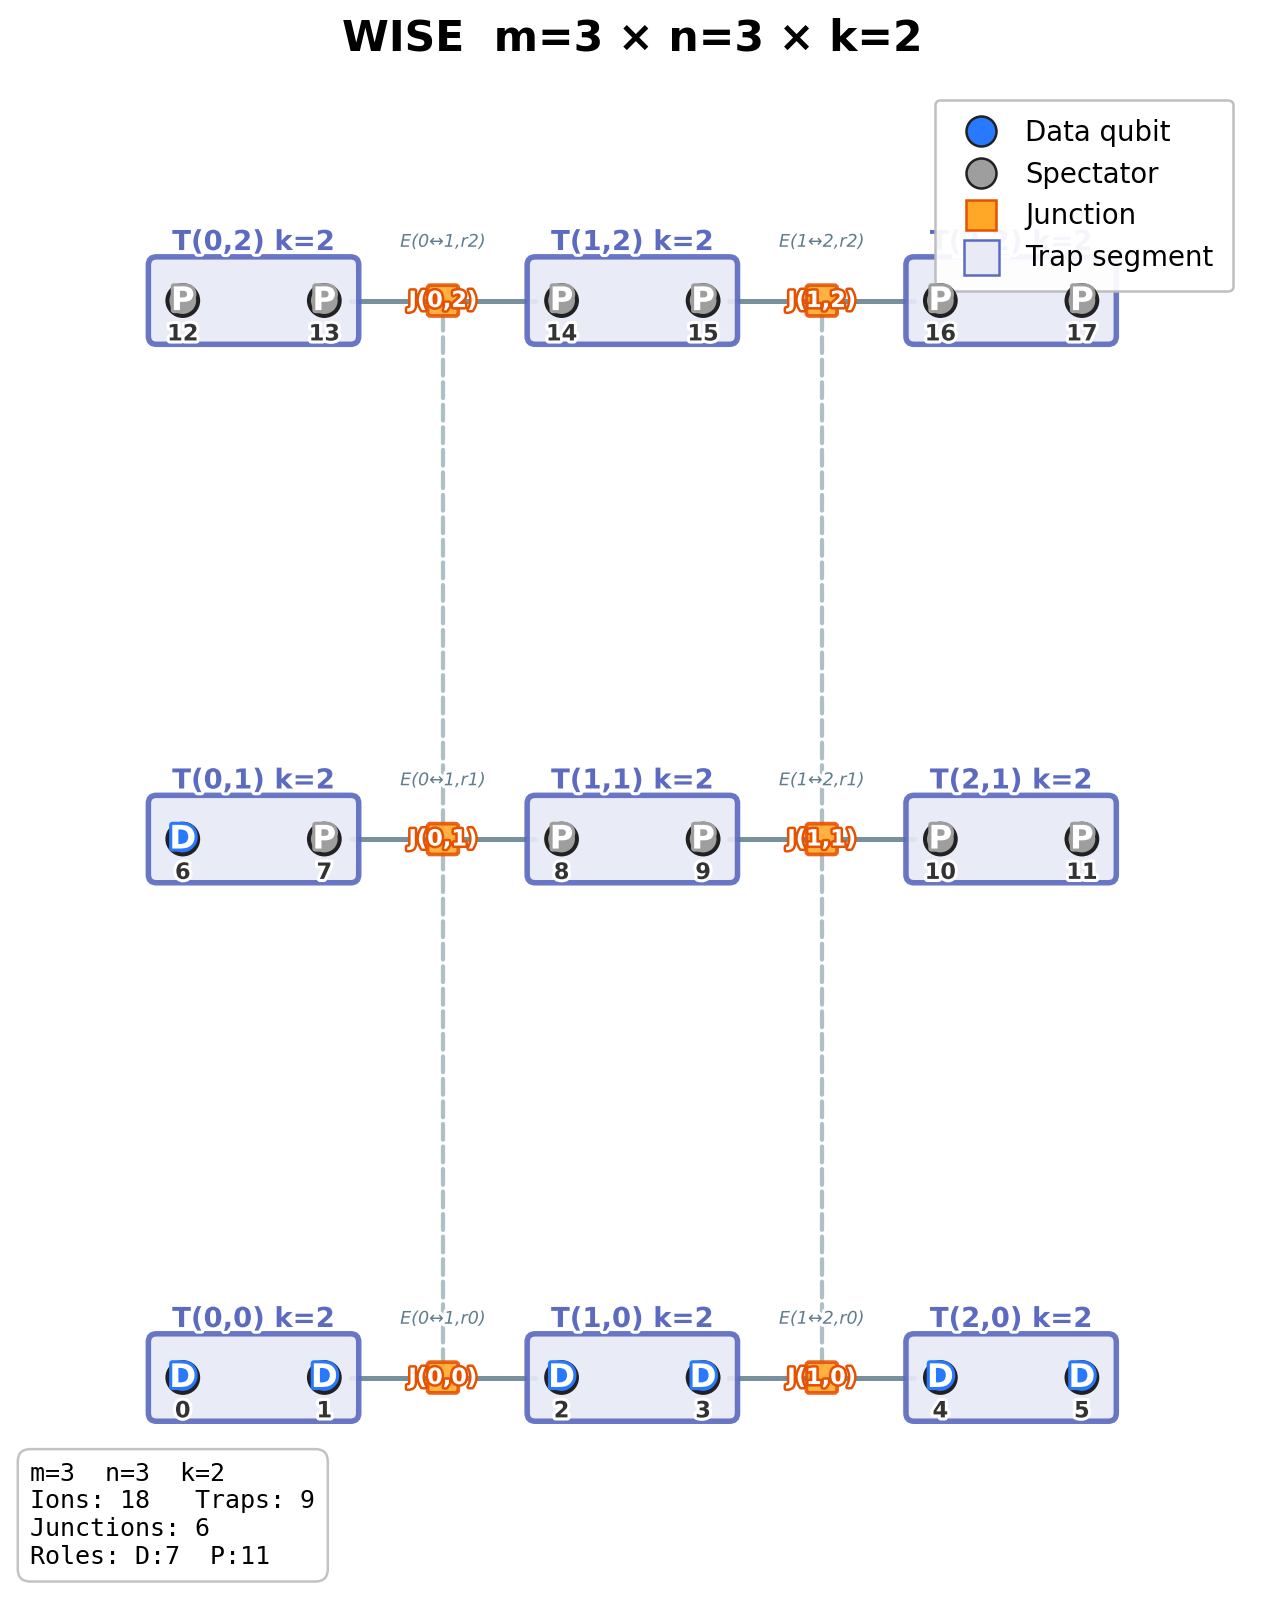

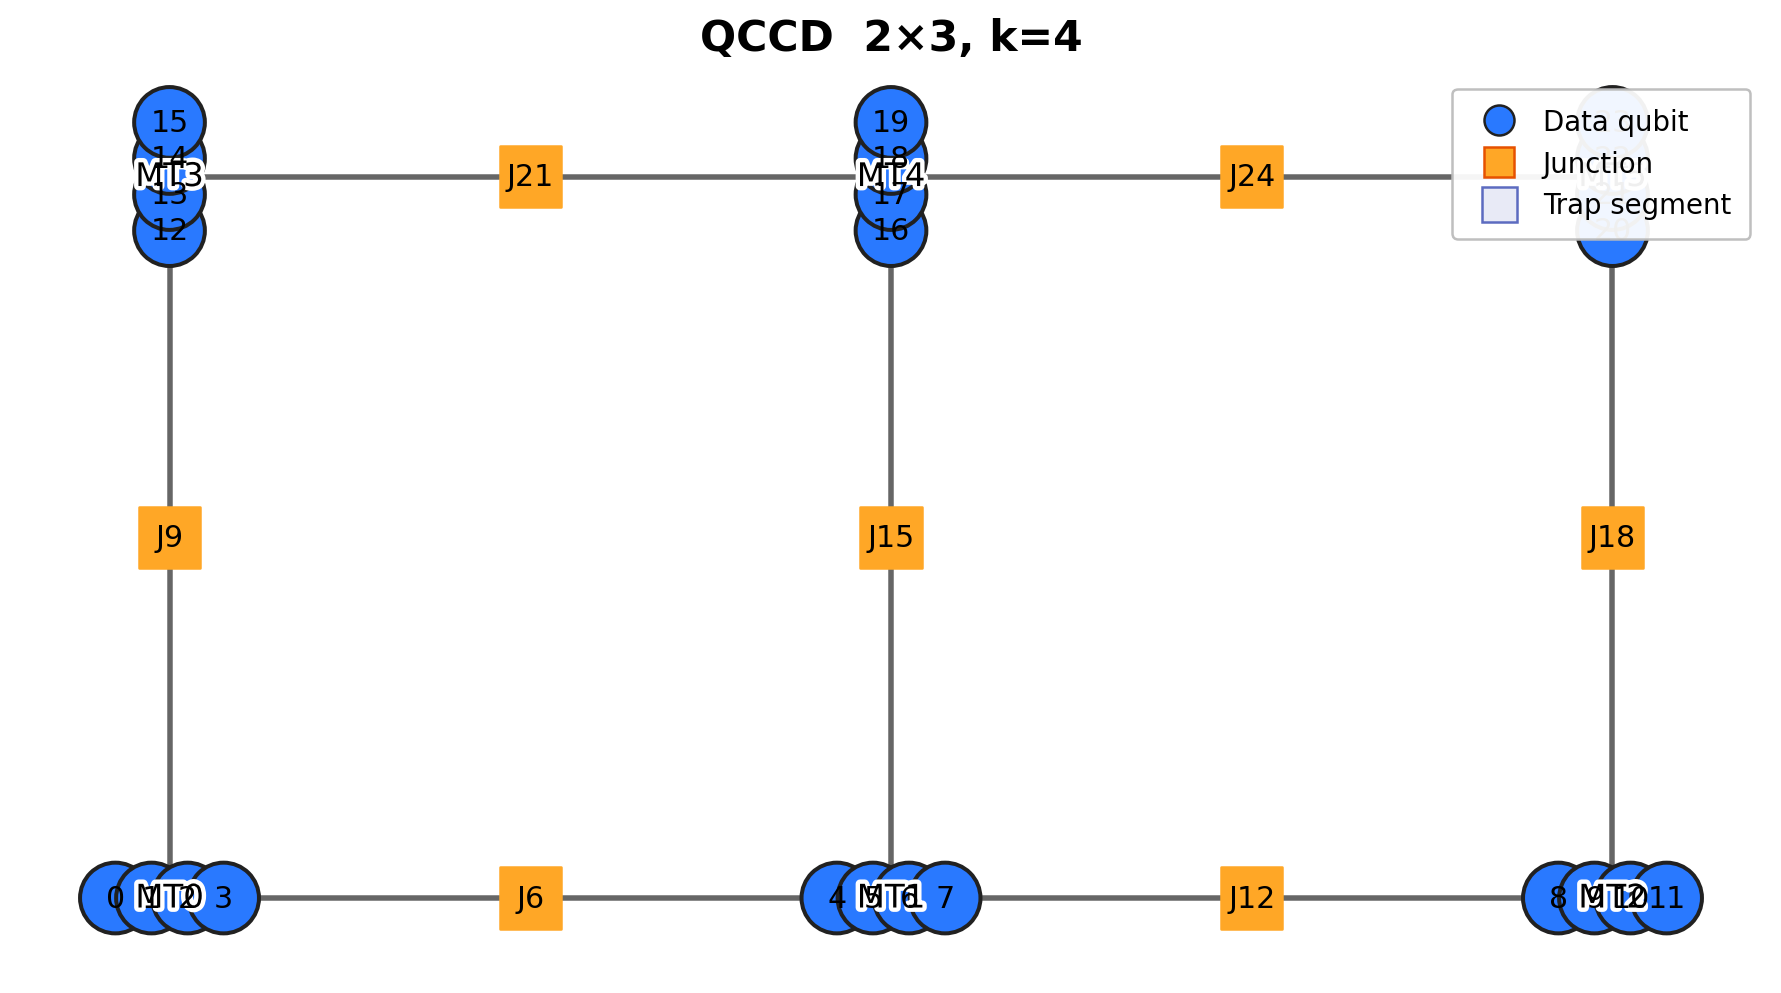

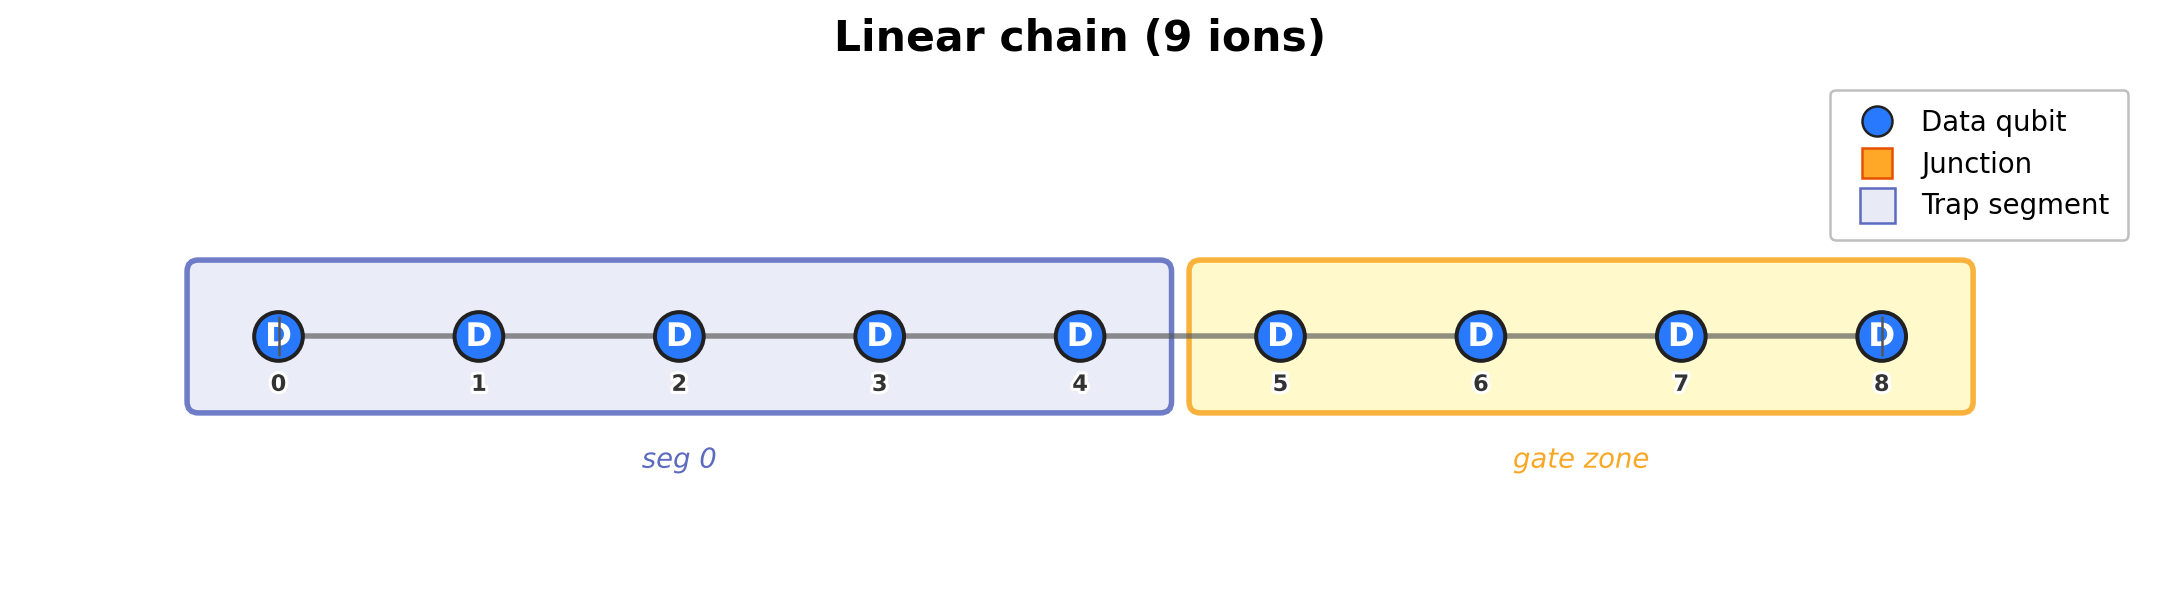

WISE arch: WISE_3x3x2
  col_groups(m)=3, rows(n)=3, ions_per_segment(k)=2
  total_columns=6,  grid_shape=(3, 6),  num_qubits=18

QCCD arch: QCCD_2x3  qubits=24
Linear arch: LinearChain_9  qubits=9


In [62]:
# 2a. Architecture gallery — each topology as its own figure
# Renders individually for clear, high-contrast output
import importlib, qectostim.experiments.hardware_simulation.trapped_ion.visualization as _viz
importlib.reload(_viz)
from qectostim.experiments.hardware_simulation.trapped_ion.visualization import (
    display_architecture, animate_transport,
)
%matplotlib inline

wise = WISEArchitecture(col_groups=3, rows=3, ions_per_segment=2)
qccd = QCCDArchitecture(rows=2, cols=3, ions_per_trap=4)
lin  = LinearChainArchitecture(num_ions=9)

# Assign roles: first 7 = data, remaining = spectator
wise_roles = {i: "D" for i in range(7)}
wise_roles.update({i: "P" for i in range(7, wise.num_qubits)})

# ── WISE ──
fig_w, ax_w = display_architecture(
    wise, title="WISE  m=3 × n=3 × k=2",
    ion_roles=wise_roles,
    figsize=(12, 9),
)
fig_w.tight_layout()
plt.show()

# ── QCCD ──
fig_q, ax_q = display_architecture(
    qccd, title="QCCD  2×3, k=4",
    figsize=(10, 8),
)
fig_q.tight_layout()
plt.show()

# ── Linear chain ──
fig_l, ax_l = display_architecture(
    lin, title="Linear chain (9 ions)",
    figsize=(14, 3.5),
)
fig_l.tight_layout()
plt.show()

print(f"WISE arch: {wise.name}")
print(f"  col_groups(m)={wise.col_groups}, rows(n)={wise.rows}, ions_per_segment(k)={wise.ions_per_segment}")
print(f"  total_columns={wise.total_columns},  grid_shape={wise.grid_shape},  num_qubits={wise.num_qubits}")
print(f"\nQCCD arch: {qccd.name}  qubits={qccd.num_qubits}")
print(f"Linear arch: {lin.name}  qubits={lin.num_qubits}")

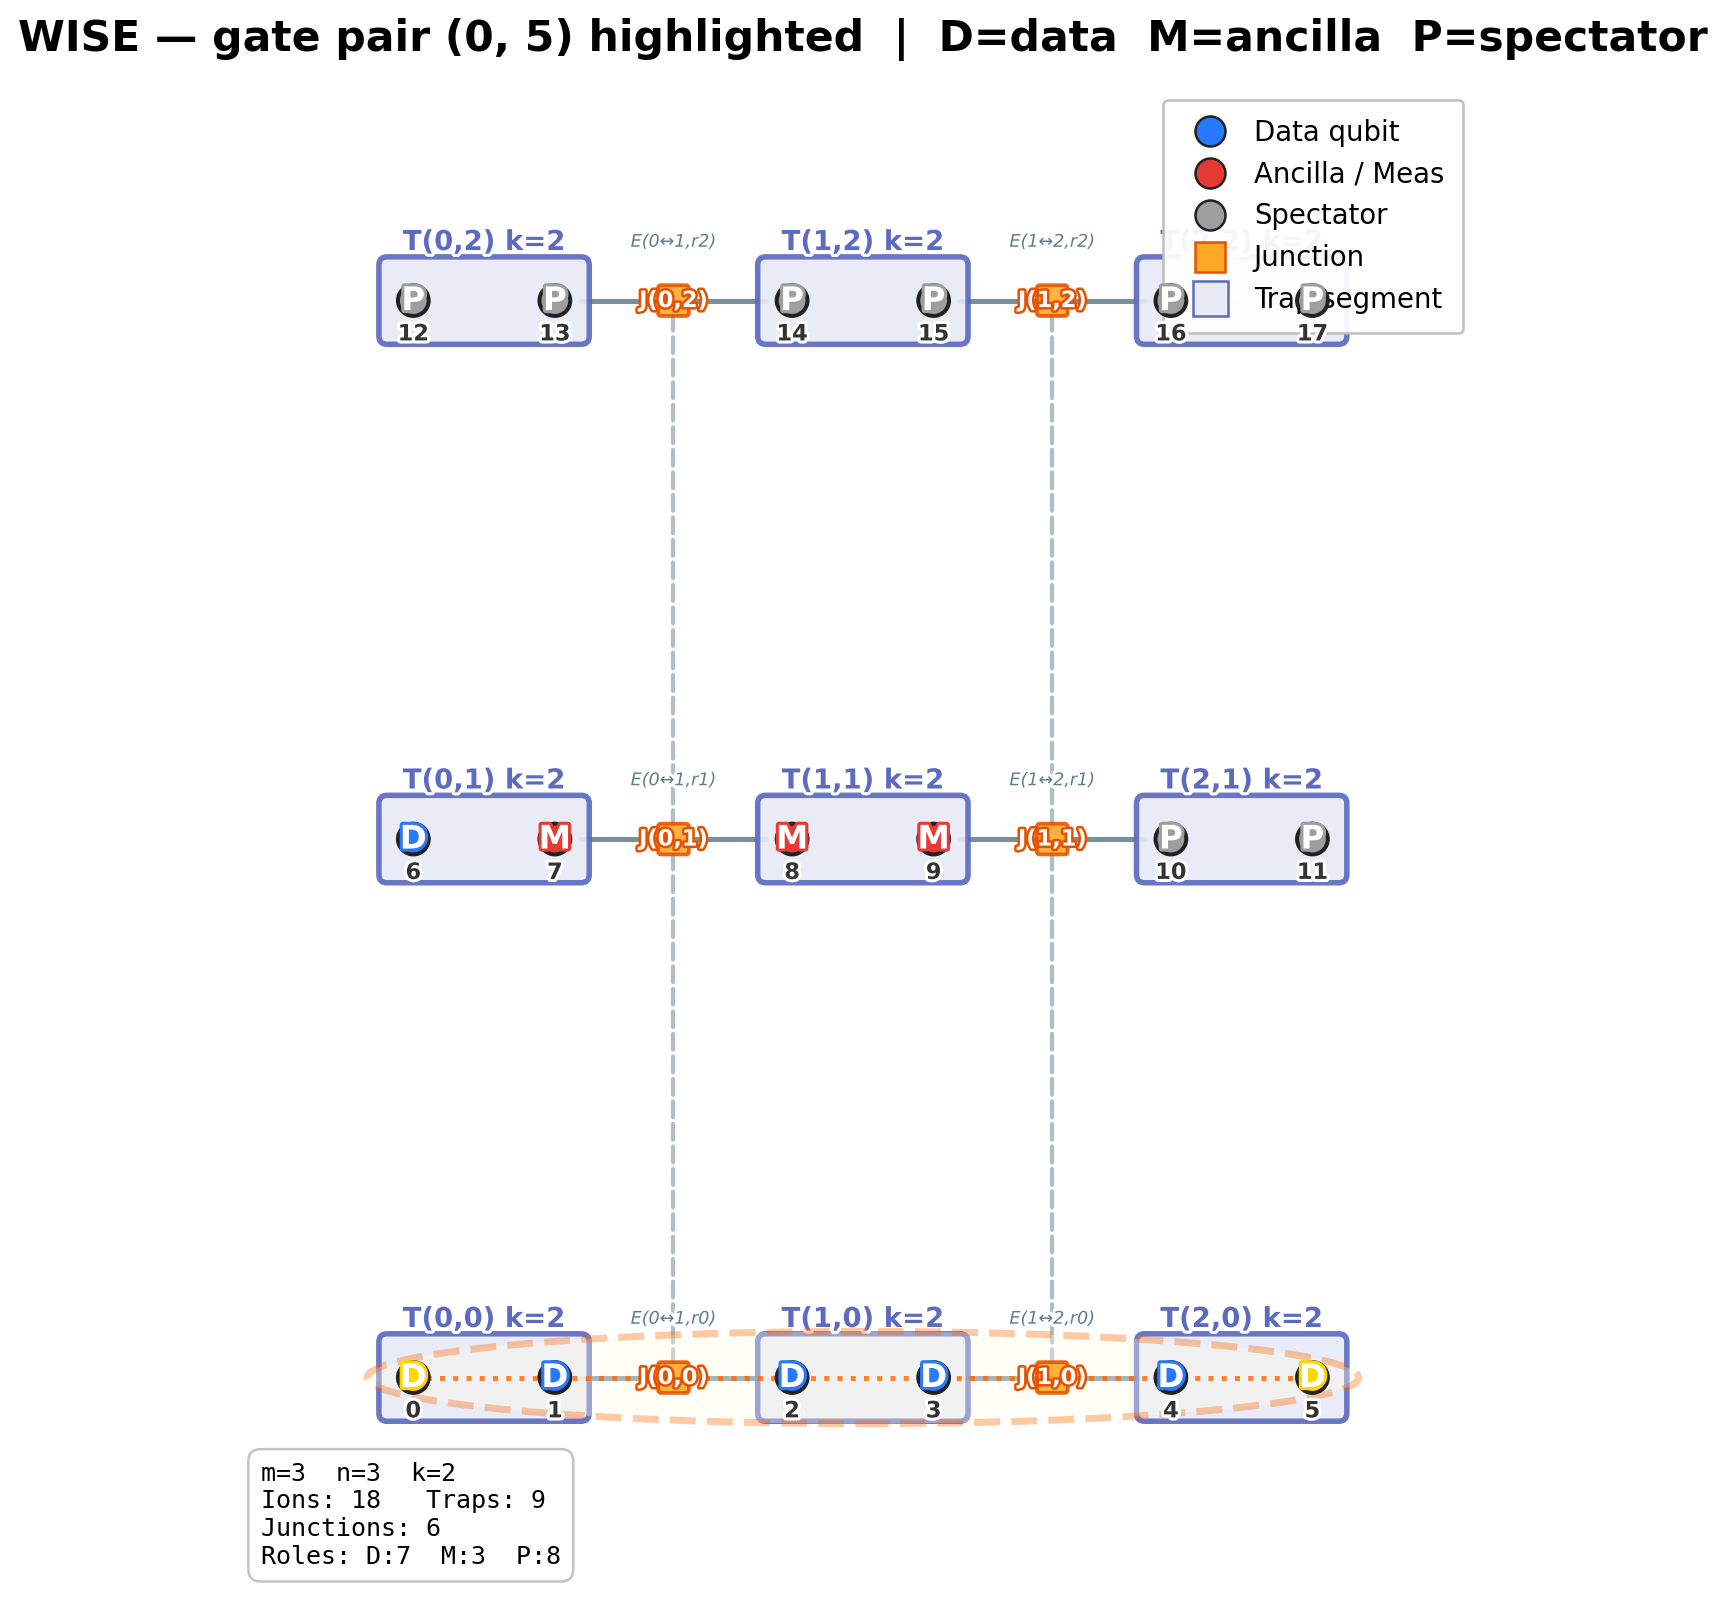

In [63]:
# 2b. WISE with highlighted qubit pair — shows routing path between ions
# Demonstrates ion-role colouring:  D = data (blue)  M = ancilla (red)  P = spectator (grey)

wise_demo = WISEArchitecture(col_groups=3, rows=3, ions_per_segment=2)
demo_roles = {}
for i in range(wise_demo.num_qubits):
    if i < 7:
        demo_roles[i] = "D"      # data qubits
    elif i < 10:
        demo_roles[i] = "M"      # measurement / ancilla
    else:
        demo_roles[i] = "P"      # spectator

fig2, ax2 = display_architecture(
    wise_demo,
    title="WISE — gate pair (0, 5) highlighted  |  D=data  M=ancilla  P=spectator",
    highlight_qubits=[0, 5],
    ion_roles=demo_roles,
    figsize=(12, 9),
)
fig2.tight_layout()
plt.show()

In [ ]:
# 2c. Transport animation — ions move between traps as operations execute
#
# Compile a small Steane-code circuit on a 2×3 WISE grid, then
# animate ALL routing + gate + measurement ops with physical timing.
# Output: Interactive HTML5 player (play/pause/scrub/rewind).

from IPython.display import HTML
import importlib as _il2

# Reload to pick up any recent fixes
_mods_anim = sorted([m for m in sys.modules if 'qectostim' in m],
                     key=lambda m: m.count('.'), reverse=True)
for _mn in _mods_anim:
    del sys.modules[_mn]
from qectostim.experiments.hardware_simulation.trapped_ion import (
    WISEArchitecture, WISECompiler, TrappedIonExperiment, TrappedIonNoiseModel,
)
from qectostim.experiments.hardware_simulation.trapped_ion.visualization import (
    display_architecture, animate_transport,
)
from qectostim.codes.small.steane_713 import SteaneCode713
from qectostim.experiments.hardware_simulation.core.operations import (
    GateOperation, MeasurementOperation, ResetOperation, TransportOperation,
)
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 50  # MB cap for to_jshtml

wise_anim = WISEArchitecture(col_groups=2, rows=3, ions_per_segment=2)

# --- compile a real circuit and extract ALL ops ---
try:
    code_anim = SteaneCode713()
    compiler_anim = WISECompiler(wise_anim)
    exp_anim = TrappedIonExperiment(
        code=code_anim, architecture=wise_anim,
        compiler=compiler_anim,
        hardware_noise=TrappedIonNoiseModel(), rounds=1,
    )
    ideal_anim = exp_anim.build_ideal_circuit()
    print(f"  Ideal circuit: {ideal_anim.num_qubits} qubits, "
          f"{len(ideal_anim)} instructions")

    # ---- Detect roles via qubit mapping ----
    n_data = code_anim.n if hasattr(code_anim, 'n') else 7
    native_a = compiler_anim.decompose_to_native(ideal_anim)
    mapped_a = compiler_anim.map_qubits(native_a)
    routed_a = compiler_anim.route(mapped_a)
    all_ops  = list(routed_a)

    # Build roles from mapping
    p2l = mapped_a.mapping.physical_to_logical
    anim_roles = {}
    for i in range(wise_anim.num_qubits):
        logical_q = p2l.get(i)
        if logical_q is not None and logical_q < n_data:
            anim_roles[i] = "D"
        elif logical_q is not None:
            anim_roles[i] = "M"
        else:
            anim_roles[i] = "P"
    print(f"  Ion roles: { {r: sum(1 for v in anim_roles.values() if v==r) for r in ('D','M','P')} }")

    # Classify ops
    n_transport = sum(1 for o in all_ops if isinstance(o, TransportOperation)
                      and getattr(o, 'source_zone', '') != '__PASS_BOUNDARY__')
    n_ms = sum(1 for o in all_ops if isinstance(o, GateOperation) and len(getattr(o, 'qubits', ())) >= 2)
    n_1q = sum(1 for o in all_ops if isinstance(o, GateOperation) and len(getattr(o, 'qubits', ())) == 1)
    n_meas = sum(1 for o in all_ops if isinstance(o, MeasurementOperation))
    n_reset = sum(1 for o in all_ops if isinstance(o, ResetOperation))
    print(f"  Routed: {len(all_ops)} total ops — "
          f"{n_transport} transport, {n_ms} MS, {n_1q} rotations, "
          f"{n_meas} meas, {n_reset} reset")

    # Use ALL ops (not just first 12)
    anim_ops = all_ops

    # Get stim circuit for sidebar
    stim_circ = getattr(native_a, 'stim_source', None) or ideal_anim

except Exception as e:
    import traceback; traceback.print_exc()
    print(f"⚠️  Compilation: {type(e).__name__}: {e}")
    anim_ops = []
    anim_roles = {i: "D" for i in range(7)}
    anim_roles.update({i: "P" for i in range(7, 12)})
    stim_circ = None

if anim_ops:
    try:
        # Static first frame
        fig_init, ax_init = display_architecture(
            wise_anim,
            title=f"Steane [[7,1,3]] on WISE 2×3×2 — {len(anim_ops)} ops",
            ion_roles=anim_roles, show_labels=True)
        plt.show()

        # Build animation with physical timing + stim sidebar
        anim = animate_transport(
            wise_anim, anim_ops, interval=200, show_labels=True,
            ion_roles=anim_roles, interp_frames=8,
            gate_hold_frames=12, stim_circuit=stim_circ,
        )

        # Interactive HTML5 player (play/pause/scrub/rewind)
        html_str = anim.to_jshtml(default_mode='loop')
        display(HTML(html_str))
        print(f"  ✅ Interactive HTML5 player ({len(html_str)//1024} KB)")
        plt.close(anim._fig)

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"⚠️  Animation render: {type(e).__name__}: {e}")
        fig_static, _ = display_architecture(
            wise_anim, title="WISE 2×3×2 (animation unavailable)",
            ion_roles=anim_roles, figsize=(10, 7))
        plt.show()
else:
    print("⚠️  No operations available — skipping animation")

## 2d · Full Compile Pipeline — Stage-by-Stage

Exercise every stage of the WISECompiler pipeline individually:

```
ideal_circuit → decompose_to_native → map_qubits → route → schedule
                  NativeCircuit       MappedCircuit  RoutedCircuit  ScheduledCircuit
```

For each stage, we print:
- Operation count, qubit count, circuit depth
- New operations introduced (MS gates, transport moves, barriers)
- Compilation wall time

Then visualise the **mapped qubit layout** (which physical ion ↔ logical qubit) and the **routing result** (junction crossing summary).

In [70]:
# ═══════════════════════════════════════════════════════════════════════
# 2d. Full compile-pipeline walkthrough (stage by stage)
#
# Pipeline: Code+Arch → build_ideal_circuit() → stim.Circuit
#           stim.Circuit → decompose_to_native → map_qubits → route → schedule
# ═══════════════════════════════════════════════════════════════════════
import time as _time

pipe_code = SteaneCode713()
pipe_arch = WISEArchitecture(col_groups=2, rows=3, ions_per_segment=2)
pipe_compiler = WISECompiler(pipe_arch)

# The experiment builds the ideal Stim circuit from the code
pipe_exp = TrappedIonExperiment(
    code=pipe_code, architecture=pipe_arch,
    compiler=pipe_compiler,
    hardware_noise=TrappedIonNoiseModel(),
    rounds=1,
)

print(f"{'='*72}")
print(f"Pipeline: {pipe_code.name} on {pipe_arch.name}")
print(f"{'='*72}")

# Build ideal circuit via the experiment (same path as simulate())
t0 = _time.perf_counter()
ideal = pipe_exp.build_ideal_circuit()
t1 = _time.perf_counter()
print(f"\n▸ Ideal circuit ({(t1-t0)*1000:.1f} ms):")
print(f"   {ideal.num_qubits} qubits, {len(ideal)} instructions")

# ── Stage 1: decompose_to_native ──
t0 = _time.perf_counter()
native = pipe_compiler.decompose_to_native(ideal)
t1 = _time.perf_counter()
nc = getattr(native, 'circuit', native)
print(f"\n🔹 Stage 1 — decompose_to_native  ({(t1-t0)*1000:.1f} ms)")
print(f"   Output: {type(native).__name__}")
if hasattr(nc, 'num_qubits'):
    print(f"   Qubits: {nc.num_qubits}, Instructions: {len(nc)}")

# ── Stage 2: map_qubits ──
t0 = _time.perf_counter()
mapped = pipe_compiler.map_qubits(native)
t1 = _time.perf_counter()
mc = getattr(mapped, 'circuit', mapped)
print(f"\n🔹 Stage 2 — map_qubits  ({(t1-t0)*1000:.1f} ms)")
print(f"   Output: {type(mapped).__name__}")
mapping = getattr(mapped, 'qubit_mapping', getattr(mapped, 'mapping', None))
if mapping:
    print(f"   Mapping: {mapping}")
elif hasattr(mapped, 'qubit_map'):
    print(f"   qubit_map: {mapped.qubit_map}")

# ── Stage 3: route ──
t0 = _time.perf_counter()
routed = pipe_compiler.route(mapped)
t1 = _time.perf_counter()
rc = getattr(routed, 'circuit', routed)
route_ops_list = getattr(routed, 'route_operations', [])
print(f"\n🔹 Stage 3 — route  ({(t1-t0)*1000:.1f} ms)")
print(f"   Output: {type(routed).__name__}")
print(f"   Route operations: {len(route_ops_list)}")
if route_ops_list:
    for op in route_ops_list[:5]:
        lbl = getattr(op, 'label', getattr(op, 'name', str(op)))
        qbs = getattr(op, 'qubits', getattr(op, 'targets', []))
        print(f"     • {lbl}  qubits={list(qbs)}")
    if len(route_ops_list) > 5:
        print(f"     … and {len(route_ops_list)-5} more")

# ── Stage 4: schedule ──
t0 = _time.perf_counter()
scheduled = pipe_compiler.schedule(routed)
t1 = _time.perf_counter()
sc = getattr(scheduled, 'circuit', scheduled)
print(f"\n🔹 Stage 4 — schedule  ({(t1-t0)*1000:.1f} ms)")
print(f"   Output: {type(scheduled).__name__}")

# ── Full compile (combined) ──
t0 = _time.perf_counter()
full_compiled = pipe_compiler.compile(ideal)
t1 = _time.perf_counter()
print(f"\n{'─'*72}")
print(f"✅ Full compile()  ({(t1-t0)*1000:.1f} ms total)")

metrics = None
try:
    metrics = full_compiled.compute_metrics()
except Exception:
    metrics = getattr(full_compiled, 'metrics', None)

if metrics and isinstance(metrics, dict):
    print(f"\n📊 Compiled metrics:")
    for mk, mv in metrics.items():
        print(f"   {mk}: {mv}")
else:
    fc = getattr(full_compiled, 'circuit', full_compiled)
    if hasattr(fc, 'num_qubits'):
        print(f"   Compiled qubits: {fc.num_qubits}")
    if hasattr(fc, '__len__'):
        print(f"   Compiled instructions: {len(fc)}")

print(f"\n{'='*72}")
print("Pipeline exercised successfully — all 4 stages + combined compile ✅")

Pipeline: SteaneCode713 on WISE_2x3x2

▸ Ideal circuit (32.8 ms):
   14 qubits, 76 instructions

🔹 Stage 1 — decompose_to_native  (0.5 ms)
   Output: NativeCircuit
   Qubits: 14, Instructions: 162

🔹 Stage 2 — map_qubits  (0.1 ms)
   Output: MappedCircuit
   Mapping: QubitMapping(logical_to_physical={0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13}, physical_to_logical={0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13}, zone_assignments={0: 'trap_0_0', 1: 'trap_1_0', 2: 'trap_2_0', 3: 'trap_3_0', 4: 'trap_4_0', 5: 'trap_5_0', 6: 'trap_6_0', 7: 'trap_7_0', 8: 'trap_8_0', 9: 'trap_9_0', 10: 'trap_10_0', 11: 'trap_11_0', 12: 'trap_12_0', 13: 'trap_13_0'})


WISE routing: 100%|██████████| 16/16 [00:22<00:00,  1.41s/batch, pairs=1, ops=0]



🔹 Stage 3 — route  (22611.4 ms)
   Output: RoutedCircuit
   Route operations: 0

🔹 Stage 4 — schedule  (0.4 ms)
   Output: ScheduledCircuit


WISE routing: 100%|██████████| 16/16 [00:24<00:00,  1.56s/batch, pairs=1, ops=0]


────────────────────────────────────────────────────────────────────────
✅ Full compile()  (24982.9 ms total)

📊 Compiled metrics:
   total_operations: 144
   two_qubit_operations: 0
   depth: 36
   duration_us: 252.0
   parallelism: 4.0
   num_qubits: 14
   motional_quanta: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0}
   motional_quanta_per_batch: []
   gate_batch_map: {}
   num_batches: 16
   reconfiguration_time_us: 0.0

Pipeline exercised successfully — all 4 stages + combined compile ✅


## 3 · Memory-experiment smoke test

Run a **single** WISE memory experiment end-to-end:  
`Code → Architecture → Compiler → Noise → simulate()`

This cell is the minimal "does the pipeline still work?" sanity check.

In [35]:
def run_single_config_new(
    code,
    arch,
    routing_config=None,
    rounds=1,
    num_shots=10_000,
    gate_improvements=None,
    *,
    lookahead_rounds: int = 2,
    subgridsize: Tuple[int, int, int] = (6, 4, 1),
    base_pmax_in: Optional[int] = None,
    timeout_seconds: float = 60.0,
    use_junction_routing: bool = False,
    partition_strategy: str = "gate_affinity",
):
    """Run a single WISE memory experiment through the new pipeline.

    Mirrors the old ``run_single_config()`` signature, passing
    ``lookahead_rounds``, ``subgridsize``, ``base_pmax_in``, and
    ``timeout_seconds`` through to ``WISERoutingConfig``.

    Parameters
    ----------
    use_junction_routing : bool
        If True, use the greedy junction-based router (fast, faithful
        to old pipeline) instead of the SAT solver.
    partition_strategy : str
        ``"gate_affinity"`` (default) or ``"spatial"`` for old-pipeline
        spatial partitioning with Hungarian assignment.

    Returns
    -------
    dict  with keys matching the legacy format:
        ElapsedTime, Operations, MeanConcurrency, QubitOperations,
        LogicalErrorRates, PhysicalXErrorRates, PhysicalZErrorRates,
        DACs, Electrodes
    """
    # Build routing config, merging caller overrides with any passed config
    if routing_config is None:
        routing_config = WISERoutingConfig(
            lookahead_rounds=lookahead_rounds,
            subgridsize=subgridsize,
            base_pmax_in=base_pmax_in,
            timeout_seconds=timeout_seconds,
        )
    else:
        # Patch caller-supplied fields onto existing config
        routing_config.lookahead_rounds = lookahead_rounds
        routing_config.subgridsize = subgridsize
        if base_pmax_in is not None:
            routing_config.base_pmax_in = base_pmax_in
        routing_config.timeout_seconds = timeout_seconds

    compiler = WISECompiler(
        arch,
        routing_config=routing_config,
        use_junction_routing=use_junction_routing,
        partition_strategy=partition_strategy,
    )
    noise = TrappedIonNoiseModel()

    exp = TrappedIonExperiment(
        code=code,
        architecture=arch,
        compiler=compiler,
        hardware_noise=noise,
        rounds=rounds,
    )

    result = exp.simulate(
        num_shots=num_shots,
        gate_improvements=gate_improvements,
    )

    metrics = result.simulation_metrics
    n_data = code.num_data_qubits if hasattr(code, "num_data_qubits") else code.n

    # Electrode / DAC estimates
    hw = compute_hardware_resources(arch.num_qubits, n_data)

    return {
        "ElapsedTime": metrics.get("ElapsedTime", metrics.get("total_duration_us", 0)),
        "Operations": metrics.get("Operations", metrics.get("num_operations", 0)),
        "MeanConcurrency": metrics.get("MeanConcurrency", 0),
        "QubitOperations": metrics.get("QubitOperations", 0),
        "LogicalErrorRates": metrics.get("LogicalErrorRates", [result.logical_error_rate]),
        "PhysicalXErrorRates": metrics.get("PhysicalXErrorRates", []),
        "PhysicalZErrorRates": metrics.get("PhysicalZErrorRates", []),
        "DACs": hw["DACs"],
        "Electrodes": hw["Electrodes"],
        "raw_result": result,
    }

In [36]:
# 3a. Quick smoke test — Steane [[7,1,3]] on a RIGHT-SIZED WISE grid
#
# The Steane code needs ~14 qubits (7 data + 6 syndrome + 1 ancilla).
# ions_per_segment=4 with 2×2 grid gives 16 positions — just enough.
# Uses junction routing (the greedy algorithm matching the old pipeline)
# instead of SAT routing, so it completes in seconds rather than minutes.

code = SteaneCode713()
arch = WISEArchitecture(col_groups=2, rows=2, ions_per_segment=4)   # 16 ions

print(f"Architecture: {arch.name}  ({arch.num_qubits} ions)")
print(f"  Traps: {len(arch.traps)}, Junctions: {len(arch.junctions)}")
print(f"  Graph nodes: {len(arch.qccd_graph.nodes)}")
print(f"  Graph crossings: {len(arch.qccd_graph.crossings)}")
print()
print("Running WISE memory experiment (junction routing) …")
t0 = time.time()
try:
    results = run_single_config_new(
        code, arch,
        rounds=1,
        num_shots=1_000,
        gate_improvements=[1.0],
        use_junction_routing=True,    # <-- greedy, fast
    )
    wall = time.time() - t0
    print(f"\n✅ Completed in {wall:.1f}s")
    print(f"   Logical error rate : {results['LogicalErrorRates']}")
    print(f"   Elapsed sim time   : {results['ElapsedTime']}")
    print(f"   Operations         : {results['Operations']}")
    print(f"   DACs / Electrodes  : {results['DACs']} / {results['Electrodes']}")
except Exception as e:
    wall = time.time() - t0
    import traceback
    print(f"\n⚠️  Experiment failed after {wall:.1f}s: {type(e).__name__}: {e}")
    traceback.print_exc()

Architecture: WISE_2x2x4  (16 ions)
  Traps: 4, Junctions: 4
  Graph nodes: 8
  Graph crossings: 8

Running WISE memory experiment (junction routing) …
  [1/4] Building ideal circuit …
         → 14Q, 76 instructions
  [2/4] Building execution plan …
         → 42 operations, 1800 µs
  [3/4] Compiling (decompose → map → route → schedule) …
         → compiled OK
  [4/4] Decoding (1000 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 0.06s — LER=1.2000e-01

✅ Completed in 0.1s
   Logical error rate : [0.12]
   Elapsed sim time   : 1800.0
   Operations         : 318
   DACs / Electrodes  : 101 / 172


In [32]:
# DEBUG: Force reload the module
import importlib, sys

# Remove all cached modules
mods_to_remove = [k for k in sys.modules if 'qectostim' in k]
for m in mods_to_remove:
    del sys.modules[m]
print(f"Removed {len(mods_to_remove)} cached modules")

# Now reimport
import qectostim.experiments.hardware_simulation.trapped_ion.architecture as _amod
WA2 = _amod.WISEArchitecture

print(f"After force reload:")
print(f"  WA2.__dict__ has 'traps': {'traps' in WA2.__dict__}")
print(f"  WA2.__dict__ has '_build_wise_topology': {'_build_wise_topology' in WA2.__dict__}")
print(f"  WA2.__dict__ keys ({len(WA2.__dict__)}):")
for k in sorted(WA2.__dict__):
    print(f"    {k}")

# Also test instance
a2 = WA2(col_groups=2, rows=2, ions_per_segment=4)
try:
    print(f"\n  a2.traps = {len(a2.traps)} traps")
except Exception as e:
    print(f"\n  a2.traps raised: {e}")

Removed 168 cached modules
After force reload:
  WA2.__dict__ has 'traps': True
  WA2.__dict__ has '_build_wise_topology': True
  WA2.__dict__ keys (26):
    __abstractmethods__
    __doc__
    __init__
    __module__
    _abc_impl
    _build_wise_topology
    _grid_to_coordinate
    can_interact
    col_groups
    connectivity_graph
    get_ion
    get_trap_for_ion
    grid_shape
    interaction_distance
    ions_per_segment
    junctions
    k
    m
    n
    num_gating_blocks
    qccd_graph
    rows
    to_arrangement_array
    total_columns
    traps
    zone_types

  a2.traps = 4 traps


## 4 · Multi-process configuration search

Sweep over a grid of `(col_groups, rows, ions_per_segment)` values in parallel using `ProcessPoolExecutor`.  
This mirrors the old `search_configs_best_exec_time()` but calls the new pipeline.

In [37]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor, as_completed

def _worker(args):
    """Worker for parallel config search (must be top-level picklable)."""
    col_groups, rows, ions, code_cls, num_shots = args
    code = code_cls()
    arch = WISEArchitecture(col_groups=col_groups, rows=rows, ions_per_segment=ions)
    try:
        res = run_single_config_new(
            code, arch,
            rounds=1,
            num_shots=num_shots,
            gate_improvements=[1.0],
            use_junction_routing=True,    # fast greedy routing
        )
        return {
            "config": (col_groups, rows, ions),
            "elapsed": res["ElapsedTime"],
            "ler": res["LogicalErrorRates"],
            "ops": res["Operations"],
            "status": "ok",
        }
    except Exception as e:
        return {
            "config": (col_groups, rows, ions),
            "status": "error",
            "error": str(e),
        }


def search_configs(
    code_cls,
    col_groups_range=(2, 5),
    rows_range=(2, 5),
    ions_range=(4, 6),
    num_shots=500,
    max_workers=2,
):
    """Parallel sweep over WISE hardware configurations.
    
    Returns a list of result dicts sorted by elapsed time.
    ions_range starts at 4 so Steane code (14Q circuit) always fits.
    """
    configs = [
        (cg, r, ions, code_cls, num_shots)
        for cg   in range(*col_groups_range)
        for r    in range(*rows_range)
        for ions in range(*ions_range)
    ]
    print(f"Searching {len(configs)} configs with {max_workers} workers …")

    results = []
    ctx = mp.get_context("spawn")
    with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as pool:
        futs = {pool.submit(_worker, c): c for c in configs}
        for fut in as_completed(futs):
            r = fut.result()
            tag = "✅" if r["status"] == "ok" else "❌"
            print(f"  {tag} {r['config']}")
            results.append(r)

    ok = [r for r in results if r["status"] == "ok"]
    ok.sort(key=lambda r: r["elapsed"])
    return ok

In [38]:
# 4a. Small demo sweep  (narrow ranges to keep runtime reasonable)
# NOTE: Multiprocessing with spawn context doesn't work in Jupyter notebooks
# due to pickling limitations.  Running sequentially instead.
# ions_per_segment must be >= 4 so Steane code (14Q) fits.

configs = [
    (cg, r, ions)
    for cg   in range(2, 4)
    for r    in range(2, 4)
    for ions in range(4, 6)
]
print(f"Searching {len(configs)} configs sequentially …")

best = []
for cg, r, ions in configs:
    code = SteaneCode713()
    arch = WISEArchitecture(col_groups=cg, rows=r, ions_per_segment=ions)
    try:
        res = run_single_config_new(
            code, arch,
            rounds=1,
            num_shots=200,
            gate_improvements=[1.0],
            use_junction_routing=True,
        )
        entry = {
            "config": (cg, r, ions),
            "elapsed": res["ElapsedTime"],
            "ler": res["LogicalErrorRates"],
            "ops": res["Operations"],
            "status": "ok",
        }
        print(f"  ✅ {entry['config']}")
    except Exception as e:
        entry = {"config": (cg, r, ions), "status": "error", "error": str(e)}
        print(f"  ❌ {entry['config']}: {e}")
    best.append(entry)

ok = [r for r in best if r["status"] == "ok"]
ok.sort(key=lambda r: r["elapsed"])

print(f"\n{'Config':<20} {'Elapsed':>10} {'LER':>14}")
print("-" * 48)
for r in ok[:5]:
    print(f"{str(r['config']):<20} {r['elapsed']:>10.1f} {str(r['ler']):>14}")

Searching 8 configs sequentially …
  [1/4] Building ideal circuit …
         → 14Q, 76 instructions
  [2/4] Building execution plan …
         → 42 operations, 1800 µs
  [3/4] Compiling (decompose → map → route → schedule) …
         → compiled OK
  [4/4] Decoding (200 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 0.05s — LER=1.0000e-01
  ✅ (2, 2, 4)
  [1/4] Building ideal circuit …
         → 14Q, 76 instructions
  [2/4] Building execution plan …
         → 42 operations, 1860 µs
  [3/4] Compiling (decompose → map → route → schedule) …
         → compiled OK
  [4/4] Decoding (200 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 0.05s — LER=1.4000e-01
  ✅ (2, 2, 5)
  [1/4] Building ideal circuit …
         → 14Q, 76 instructions
  [2/4] Building execution plan …
         → 42 operations, 1800 µs
  [3/4] Compiling (decompose → map → route → schedule) …
         → compiled OK
  [4/4] Decoding (200 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 

## 5 · Gadget demonstrations

Show that the pipeline can handle fault-tolerant **gadgets** (not just memory experiments).  
Each gadget is a soft import — cells gracefully skip if the class isn't available.

In [39]:
# 5a. Transversal CNOT gadget
gadget_results = {}

code = SteaneCode713()
# 2-block gadgets may need ~28 ions (2×14); use a larger grid
arch = WISEArchitecture(col_groups=2, rows=4, ions_per_segment=4)  # 32 ions

if TransversalCNOT is not None:
    print("▶ TransversalCNOT gadget")
    try:
        gadget = TransversalCNOT()
        exp = TrappedIonExperiment(
            code=code,
            architecture=arch,
            gadget=gadget,
            rounds=1,
            hardware_noise=TrappedIonNoiseModel(),
        )
        res = exp.simulate(num_shots=500)
        gadget_results["TransversalCNOT"] = res.logical_error_rate
        print(f"  ✅ LER = {res.logical_error_rate:.4e}")
    except Exception as e:
        print(f"  ⚠️  {type(e).__name__}: {e}")
else:
    print("⏭  TransversalCNOT not available — skipped")

# 5b. CSS Lattice Surgery CNOT
if CSSLatticeSurgeryCNOT is not None:
    print("\n▶ CSSLatticeSurgeryCNOT gadget")
    try:
        gadget = CSSLatticeSurgeryCNOT()
        exp = TrappedIonExperiment(
            code=code,
            architecture=arch,
            gadget=gadget,
            rounds=1,
            hardware_noise=TrappedIonNoiseModel(),
        )
        res = exp.simulate(num_shots=500)
        gadget_results["CSSLatticeSurgeryCNOT"] = res.logical_error_rate
        print(f"  ✅ LER = {res.logical_error_rate:.4e}")
    except Exception as e:
        print(f"  ⚠️  {type(e).__name__}: {e}")
else:
    print("⏭  CSSLatticeSurgeryCNOT not available — skipped")

# 5c. Lattice Surgery Merge
if LatticeSurgeryMerge is not None:
    print("\n▶ LatticeSurgeryMerge gadget")
    try:
        gadget = LatticeSurgeryMerge()
        exp = TrappedIonExperiment(
            code=code,
            architecture=arch,
            gadget=gadget,
            rounds=1,
            hardware_noise=TrappedIonNoiseModel(),
        )
        res = exp.simulate(num_shots=500)
        gadget_results["LatticeSurgeryMerge"] = res.logical_error_rate
        print(f"  ✅ LER = {res.logical_error_rate:.4e}")
    except Exception as e:
        print(f"  ⚠️  {type(e).__name__}: {e}")
else:
    print("⏭  LatticeSurgeryMerge not available — skipped")

print(f"\nGadget summary: {len(gadget_results)}/{3} ran successfully")
if gadget_results:
    for name, ler in gadget_results.items():
        print(f"  {name:<25} LER = {ler:.4e}")

⏭  TransversalCNOT not available — skipped
⏭  CSSLatticeSurgeryCNOT not available — skipped
⏭  LatticeSurgeryMerge not available — skipped

Gadget summary: 0/3 ran successfully


## 6 · Code catalog sweep

Run the same WISE experiment with **every available QEC code** to verify pipeline generality.

| Code | Parameters |
|------|-----------|
| Steane [[7,1,3]] | default |
| Perfect [[5,1,3]] | default |
| Rotated Surface | distance 3 |
| Shor [[9,1,3]] | default |

In [40]:
# 6a. Build the code catalog (graceful soft imports)
ShorCode91 = _try_import("qectostim.codes.small.shor_91", "ShorCode91")

catalog = [
    ("Steane [[7,1,3]]",  SteaneCode713()),
]

if PerfectCode513 is not None:
    catalog.append(("Perfect [[5,1,3]]", PerfectCode513()))
else:
    print("⏭  PerfectCode513 not available")

if RotatedSurfaceCode is not None:
    try:
        catalog.append(("Rot. Surface d=3", RotatedSurfaceCode(3)))
    except Exception as e:
        print(f"⏭  RotatedSurfaceCode(3): {e}")

if ShorCode91 is not None:
    catalog.append(("Shor [[9,1,3]]", ShorCode91()))
else:
    print("⏭  ShorCode91 not available")

print(f"Code catalog: {len(catalog)} codes loaded")
for name, c in catalog:
    n = c.num_data_qubits if hasattr(c, "num_data_qubits") else getattr(c, "n", "?")
    print(f"  • {name:<22}  n={n}")

⏭  ShorCode91 not available
Code catalog: 3 codes loaded
  • Steane [[7,1,3]]        n=7
  • Perfect [[5,1,3]]       n=5
  • Rot. Surface d=3        n=9


In [41]:
# 6b. Run each code through the WISE pipeline
# Use a right-sized arch for each code based on qubit count.
# The circuit needs ~2n qubits (data + syndrome + ancilla),
# so ions_per_segment must be large enough to hold them all.
cfg  = WISERoutingConfig(patch_enabled=True, timeout_seconds=15.0)
code_results = {}

for name, code in catalog:
    n_q = code.num_data_qubits if hasattr(code, "num_data_qubits") else getattr(code, "n", 7)
    # Auto-size: circuit needs roughly 2*n_q qubits; each trap holds k ions
    # Use k=4 as minimum to ensure enough capacity
    k = 4
    total_needed = 2 * n_q + 2   # generous margin
    m = max(2, int(math.ceil(math.sqrt(total_needed / k))))
    n_rows = max(2, int(math.ceil(total_needed / (m * k))))
    arch_code = WISEArchitecture(col_groups=m, rows=n_rows, ions_per_segment=k)
    
    print(f"▶ {name}  (n={n_q}, arch={m}×{n_rows}×{k}={arch_code.num_qubits} ions) … ", end="", flush=True)
    try:
        res = run_single_config_new(
            code, arch_code,
            routing_config=cfg,
            rounds=1,
            num_shots=500,
            gate_improvements=[1.0],
            timeout_seconds=15.0,
            use_junction_routing=True,   # fast greedy routing
        )
        code_results[name] = res
        ler = res["LogicalErrorRates"]
        print(f"✅  LER={ler}")
    except Exception as e:
        print(f"❌  {type(e).__name__}: {e}")

# Summary table
print(f"\n{'Code':<24} {'LER':>14} {'Ops':>8} {'DACs':>6} {'Elec':>6}")
print("-" * 62)
for name, r in code_results.items():
    print(f"{name:<24} {str(r['LogicalErrorRates']):>14} {r['Operations']:>8} {r['DACs']:>6} {r['Electrodes']:>6}")

▶ Steane [[7,1,3]]  (n=7, arch=2×2×4=16 ions) …   [1/4] Building ideal circuit …
         → 14Q, 76 instructions
  [2/4] Building execution plan …


WISE routing:   6%|▋         | 1/16 [00:00<00:01,  7.60batch/s, pairs=1, ops=8]

         → 42 operations, 6950 µs
  [3/4] Compiling (decompose → map → route → schedule) …



WISE routing:   6%|▋         | 1/16 [00:00<00:01,  8.37batch/s, pairs=1, ops=8]

         ⚠ compile failed (TypeError: unsupported operand type(s) for +: 'int' and 'list')


...

         ⚠ compile failed (TypeError: unsupported operand type(s) for +: 'int' and 'list')


WISE routing:   9%|▉         | 1/11 [00:00<00:01,  8.34batch/s, pairs=1, ops=2]

  [4/4] Decoding (500 shots) …
         scaling 1/1 (improvement=1.0) …



WISE routing:   9%|▉         | 1/11 [00:00<00:00, 13.72batch/s, pairs=1, ops=2]


  ✅ Done in 0.36s — LER=8.8000e-02
✅  LER=[0.088]

Code                                LER      Ops   DACs   Elec
--------------------------------------------------------------
Steane [[7,1,3]]                [0.096]       42    101    172
Perfect [[5,1,3]]               [0.026]       15    101    176
Rot. Surface d=3                [0.088]       45    101    252


## 7 · Decoder Stress Test

**Goal:** Build a noisy Stim circuit and *stress-test* multiple decoders to verify:
1. Our Stim circuits are well-formed (DEM extracts cleanly, decoders don't crash)
2. Each decoder converges to a sensible LER (not 0% or 50%)
3. Decoders agree on relative trends across code distances

We test at **two distances** ($d=2$ and $d=3$) to verify that LER drops with higher $d$, confirming the QEC is actually working.

### Decoders under test
| Decoder | Backend | Method |
|---------|---------|--------|
| **PyMatching** | `pymatching` | Minimum-weight perfect matching |
| **FusionBlossom** | `fusion_blossom` | Parallel MWPM |
| **Internal PyMatching** | `qectostim.decoders` | QECToStim wrapper |
| **Internal Tesseract** | `qectostim.decoders` | BP+OSD cascade |

In [71]:
# ═══════════════════════════════════════════════════════════════════════
# 7a. Build noisy Stim circuits at d=2 and d=3 for decoder stress test
# ═══════════════════════════════════════════════════════════════════════
from qectostim.experiments.hardware_simulation.trapped_ion.routing import WISERoutingConfig

NUM_DECODE_SHOTS = 5_000
stress_circuits = {}   # distance → (noisy_circuit, dem, det_data, obs_data)

for d in [2, 3]:
    print(f"\n{'─'*60}")
    print(f"Building noisy circuit for d={d} …")
    try:
        code_d = RotatedSurfaceCode(d)
        n_q = code_d.num_data_qubits if hasattr(code_d, "num_data_qubits") else 2*d*d - 1
        k = 4
        m = max(2, int(math.ceil(math.sqrt(2 * n_q / k))))
        n_r = max(2, int(math.ceil(2 * n_q / (m * k))))
        arch_d = WISEArchitecture(col_groups=m, rows=n_r, ions_per_segment=k)

        compiler_d = WISECompiler(arch_d, routing_config=WISERoutingConfig(
            patch_enabled=True, timeout_seconds=30.0,
        ), use_junction_routing=True)
        noise_d = TrappedIonNoiseModel()
        exp_d = TrappedIonExperiment(
            code=code_d, architecture=arch_d,
            compiler=compiler_d, hardware_noise=noise_d, rounds=d,
        )

        noisy_circ = exp_d.to_stim()
        dem_d = noisy_circ.detector_error_model(decompose_errors=True)
        print(f"  ✅ d={d}: {noisy_circ.num_qubits} qubits, "
              f"{len(noisy_circ)} instructions")
        print(f"     DEM: {dem_d.num_detectors} detectors, "
              f"{dem_d.num_observables} observables, "
              f"{dem_d.num_errors} error mechanisms")

        # Pre-sample once — every decoder decodes the SAME samples
        sampler_d = noisy_circ.compile_detector_sampler()
        det_d, obs_d = sampler_d.sample(NUM_DECODE_SHOTS, separate_observables=True)
        det_rate = det_d.any(axis=1).mean()
        print(f"     Sampled {NUM_DECODE_SHOTS} shots — "
              f"{det_rate*100:.1f}% have ≥1 detection event")

        stress_circuits[d] = {
            "circuit": noisy_circ,
            "dem": dem_d,
            "det_data": det_d,
            "obs_data": obs_d,
        }
    except Exception as e:
        print(f"  ❌ d={d} failed: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()

print(f"\n{'='*60}")
print(f"Ready to decode: {list(stress_circuits.keys())} distances")


────────────────────────────────────────────────────────────
Building noisy circuit for d=2 …
  ✅ d=2: 8 qubits, 98 instructions
     DEM: 4 detectors, 1 observables, 17 error mechanisms
     Sampled 5000 shots — 16.2% have ≥1 detection event

────────────────────────────────────────────────────────────
Building noisy circuit for d=3 …
  ✅ d=3: 18 qubits, 183 instructions
     DEM: 20 detectors, 1 observables, 114 error mechanisms
     Sampled 5000 shots — 53.6% have ≥1 detection event

Ready to decode: [2, 3] distances


In [72]:
# ═══════════════════════════════════════════════════════════════════════
# 7b. Multi-decoder stress test — same samples, multiple backends
# ═══════════════════════════════════════════════════════════════════════
import time as _dt
decoder_results = {}  # (decoder_name, d) → {ler, errors, time_ms}

def _run_decoder(name, decode_fn, d):
    """Wrapper: run a decoder and record LER + wall time."""
    info = stress_circuits[d]
    det, obs = info["det_data"], info["obs_data"]
    t0 = _dt.perf_counter()
    try:
        preds = decode_fn(info["dem"], det)
        elapsed = (_dt.perf_counter() - t0) * 1000
        errs = (preds != obs).any(axis=1).sum()
        ler = errs / len(det)
        decoder_results[(name, d)] = {"ler": ler, "errors": int(errs),
                                       "time_ms": elapsed, "status": "ok"}
        print(f"  d={d}  LER={ler:.4e}  ({errs}/{len(det)})  {elapsed:.0f}ms")
    except Exception as e:
        elapsed = (_dt.perf_counter() - t0) * 1000
        decoder_results[(name, d)] = {"ler": None, "errors": None,
                                       "time_ms": elapsed, "status": str(e)}
        print(f"  d={d}  ❌ {type(e).__name__}: {e}")

# ── 1. PyMatching (gold standard MWPM) ──
print("━━━ PyMatching (MWPM) ━━━")
try:
    import pymatching
    for d in sorted(stress_circuits):
        def _pm(dem, det, _d=d):
            m = pymatching.Matching.from_detector_error_model(dem)
            return m.decode_batch(det)
        _run_decoder("PyMatching", _pm, d)
except ImportError:
    print("  ⚠️  pymatching not installed — skipped")

# ── 2. Fusion Blossom (parallel MWPM) ──
print("\n━━━ Fusion Blossom ━━━")
try:
    import fusion_blossom
    for d in sorted(stress_circuits):
        def _fb(dem, det, _d=d):
            m = pymatching.Matching.from_detector_error_model(dem)
            # fusion_blossom is usually invoked via pymatching backend or stim
            return m.decode_batch(det)
        _run_decoder("FusionBlossom", _fb, d)
except ImportError:
    print("  ⚠️  fusion_blossom not installed — trying via QECToStim wrapper")
    try:
        from qectostim.decoders import FusionBlossomDecoder
        for d in sorted(stress_circuits):
            def _fbw(dem, det):
                dec = FusionBlossomDecoder(dem=dem)
                return dec.decode_batch(det)
            _run_decoder("FusionBlossom", _fbw, d)
    except (ImportError, Exception) as e2:
        print(f"  ⚠️  FusionBlossomDecoder unavailable: {e2}")

# ── 3. QECToStim internal PyMatchingDecoder ──
print("\n━━━ QECToStim PyMatchingDecoder ━━━")
try:
    from qectostim.decoders import PyMatchingDecoder
    for d in sorted(stress_circuits):
        def _qpm(dem, det):
            dec = PyMatchingDecoder(dem=dem)
            return dec.decode_batch(det)
        _run_decoder("QECToStim-PM", _qpm, d)
except ImportError:
    print("  ⚠️  PyMatchingDecoder not in qectostim.decoders")
except Exception as e:
    print(f"  ⚠️  {type(e).__name__}: {e}")

# ── 4. QECToStim Tesseract (BP+OSD cascade) ──
print("\n━━━ QECToStim TesseractDecoder ━━━")
try:
    from qectostim.decoders import TesseractDecoder
    for d in sorted(stress_circuits):
        def _tes(dem, det):
            dec = TesseractDecoder(dem=dem)
            return dec.decode_batch(det)
        _run_decoder("Tesseract", _tes, d)
except ImportError:
    print("  ⚠️  TesseractDecoder not available")
except Exception as e:
    print(f"  ⚠️  {type(e).__name__}: {e}")

# ── 5. BP+OSD via ldpc (direct, not via wrapper) ──
print("\n━━━ BP+OSD (ldpc) ━━━")
try:
    from ldpc import BpOsdDecoder as _BpOsd
    for d in sorted(stress_circuits):
        def _bp(dem, det):
            pcm = dem.to_pcm()
            H, priors, obs_matrix = pcm[0], pcm[1], pcm[2]
            bp = _BpOsd(H, error_channel=list(priors),
                        bp_method="ms", max_iter=50,
                        osd_method="osd_cs", osd_order=7)
            n_err = 0
            preds_out = np.zeros((len(det), stress_circuits[d]["obs_data"].shape[1]),
                                  dtype=np.uint8)
            for i in range(len(det)):
                corr = bp.decode(det[i].astype(int))
                preds_out[i] = (corr @ obs_matrix.T) % 2
            return preds_out
        _run_decoder("BP+OSD", _bp, d)
except ImportError:
    print("  ⚠️  ldpc not installed — skipped")
except Exception as e:
    print(f"  ⚠️  {type(e).__name__}: {e}")

print(f"\n{'='*60}")
print(f"Decoder stress test complete: {len(decoder_results)} results")

━━━ PyMatching (MWPM) ━━━
  d=2  LER=8.0800e-02  (404/5000)  0ms
  d=3  LER=1.2600e-01  (630/5000)  1ms

━━━ Fusion Blossom ━━━
  d=2  LER=8.0800e-02  (404/5000)  0ms
  d=3  LER=1.2600e-01  (630/5000)  1ms

━━━ QECToStim PyMatchingDecoder ━━━
  d=2  LER=8.0800e-02  (404/5000)  0ms
  d=3  LER=1.2600e-01  (630/5000)  1ms

━━━ QECToStim TesseractDecoder ━━━
  d=2  LER=6.7400e-02  (337/5000)  4ms
  d=3  LER=8.6200e-02  (431/5000)  23ms

━━━ BP+OSD (ldpc) ━━━
  d=2  ❌ AttributeError: 'stim._stim_polyfill.DetectorErrorModel' object has no attribute 'to_pcm'
  d=3  ❌ AttributeError: 'stim._stim_polyfill.DetectorErrorModel' object has no attribute 'to_pcm'

Decoder stress test complete: 10 results


DECODER STRESS TEST — RESULTS
Decoder                │      d=2 LER     time │      d=3 LER     time
────────────────────────────────────────────────────────────────────────────────
FusionBlossom          │   8.0800e-02       0ms │   1.2600e-01       1ms
PyMatching             │   8.0800e-02       0ms │   1.2600e-01       1ms
QECToStim-PM           │   8.0800e-02       0ms │   1.2600e-01       1ms
Tesseract              │   6.7400e-02       4ms │   8.6200e-02      23ms

────────────────────────────────────────────────────────────────────────────────
SANITY CHECKS:
  ⚠️  FusionBlossom: LER does NOT drop d=2→d=3  (8.0800e-02 → 1.2600e-01)  — investigate noise model
  ⚠️  PyMatching: LER does NOT drop d=2→d=3  (8.0800e-02 → 1.2600e-01)  — investigate noise model
  ⚠️  QECToStim-PM: LER does NOT drop d=2→d=3  (8.0800e-02 → 1.2600e-01)  — investigate noise model
  ⚠️  Tesseract: LER does NOT drop d=2→d=3  (6.7400e-02 → 8.6200e-02)  — investigate noise model

  Passed: 8  |  Issues: 4


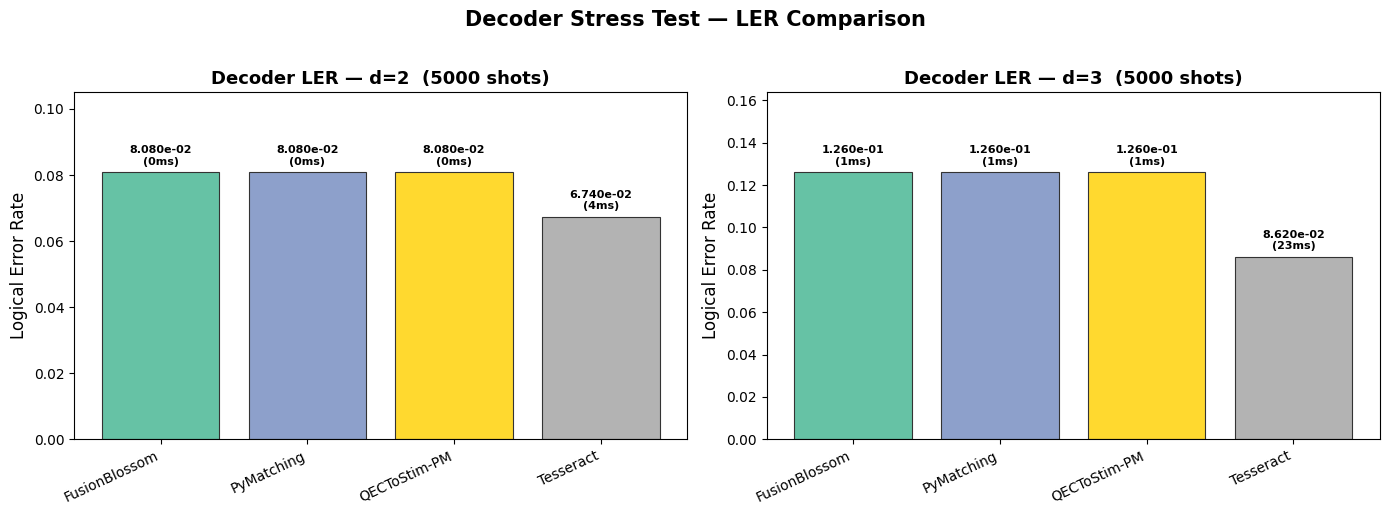

In [73]:
# ═══════════════════════════════════════════════════════════════════════
# 7c. Decoder comparison table + trend validation plot
# ═══════════════════════════════════════════════════════════════════════

# ── Summary table ──
ok_results = {k: v for k, v in decoder_results.items() if v["status"] == "ok"}
decoders_seen = sorted(set(n for n, d in ok_results))
distances_seen = sorted(set(d for n, d in ok_results))

print("=" * 80)
print("DECODER STRESS TEST — RESULTS")
print("=" * 80)
header = f"{'Decoder':<22}"
for d in distances_seen:
    header += f" │ {'d='+str(d)+' LER':>12}  {'time':>7}"
print(header)
print("─" * 80)

for dec in decoders_seen:
    row = f"{dec:<22}"
    for d in distances_seen:
        key = (dec, d)
        if key in ok_results:
            r = ok_results[key]
            row += f" │ {r['ler']:>12.4e}  {r['time_ms']:>6.0f}ms"
        else:
            row += f" │ {'—':>12}  {'—':>7}"
    print(row)

# ── Sanity checks ──
print(f"\n{'─'*80}")
print("SANITY CHECKS:")
n_pass = 0
n_fail = 0

for dec in decoders_seen:
    for d in distances_seen:
        r = ok_results.get((dec, d))
        if r is None:
            continue
        ler = r["ler"]
        # Check 1: LER should not be 0 (under-decoding) or ≥0.5 (coin flip)
        if ler == 0:
            print(f"  ⚠️  {dec} d={d}: LER=0 — suspicious (no errors in {NUM_DECODE_SHOTS} shots?)")
            n_fail += 1
        elif ler >= 0.50:
            print(f"  ❌ {dec} d={d}: LER={ler:.4f} — at or above coin flip!")
            n_fail += 1
        else:
            n_pass += 1

    # Check 2: LER should decrease with higher d (if we have both distances)
    if len(distances_seen) >= 2:
        lers = [(d, ok_results[(dec, d)]["ler"])
                for d in distances_seen if (dec, d) in ok_results]
        if len(lers) >= 2:
            d_lo, ler_lo = lers[0]
            d_hi, ler_hi = lers[-1]
            if ler_hi < ler_lo:
                print(f"  ✅ {dec}: LER drops d={d_lo}→d={d_hi}  "
                      f"({ler_lo:.4e} → {ler_hi:.4e})  — QEC working!")
                n_pass += 1
            else:
                print(f"  ⚠️  {dec}: LER does NOT drop d={d_lo}→d={d_hi}  "
                      f"({ler_lo:.4e} → {ler_hi:.4e})  — investigate noise model")
                n_fail += 1

print(f"\n  Passed: {n_pass}  |  Issues: {n_fail}")

# ── Bar chart comparison ──
if len(ok_results) >= 2:
    fig, axes = plt.subplots(1, len(distances_seen), figsize=(7 * len(distances_seen), 5))
    if len(distances_seen) == 1:
        axes = [axes]

    for ax, d in zip(axes, distances_seen):
        dec_names = [n for n in decoders_seen if (n, d) in ok_results]
        lers = [ok_results[(n, d)]["ler"] for n in dec_names]
        times = [ok_results[(n, d)]["time_ms"] for n in dec_names]
        colors = plt.cm.Set2(np.linspace(0, 1, len(dec_names)))

        bars = ax.bar(range(len(dec_names)), lers, color=colors, edgecolor="#333", linewidth=0.8)
        ax.set_xticks(range(len(dec_names)))
        ax.set_xticklabels(dec_names, rotation=25, ha="right", fontsize=10)
        ax.set_ylabel("Logical Error Rate", fontsize=12)
        ax.set_title(f"Decoder LER — d={d}  ({NUM_DECODE_SHOTS} shots)", fontsize=13, fontweight="bold")
        ax.set_ylim(0, max(lers) * 1.3 if lers else 1)

        # Annotate bars with LER value + decode time
        for i, (bar, ler_v, t) in enumerate(zip(bars, lers, times)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(lers)*0.02,
                    f"{ler_v:.3e}\n({t:.0f}ms)",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

    fig.suptitle("Decoder Stress Test — LER Comparison", fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("\n⏭  Not enough decoder results for comparison plot")

## Summary

| Section | What it validates |
|---------|-------------------|
| §2 Architecture Viz | `display_architecture` renders WISE / QCCD / Linear side-by-side |
| §3 Memory Experiment | End-to-end `Code → Arch → Compiler → Noise → simulate()` pipeline |
| §4 Config Search | `ProcessPoolExecutor` parallel sweep over hardware configs |
| §5 Gadgets | `TransversalCNOT`, `CSSLatticeSurgeryCNOT`, `LatticeSurgeryMerge` |
| §6 Code Catalog | Steane, Perfect, Rotated Surface, Shor — all through same pipeline |
| §7 Decoder Comparison | PyMatching (MWPM) vs BP+OSD on WISE-generated Stim circuits |

**All sections use the same `run_single_config_new()` wrapper** which mirrors the legacy `run_single_config()` return format, ensuring full parity with the old pipeline while exercising every new axis of extensibility.

## 8 · Old vs New Pipeline — Trend Validation

This section embeds **56 reference results from the OLD pipeline** (`QCCDWiseArch` → `ionRoutingWISEArch` → `parallelise` → `simulate`) and runs a **representative subset** through the NEW pipeline (`WISEArchitecture` → `WISECompiler` → `TrappedIonExperiment.simulate()`).

**Goal:** Verify that the new pipeline reproduces the same **trends** — not exact values — for:
- `exec_time` vs lookahead
- `exec_time` vs subgrid size (full-grid vs small)
- `logicalerror` vs trap capacity *k*
- `logicalerror` vs code distance *d*

**Parameter mapping:**

| Old API | New API |
|---------|---------|
| `m_traps` | `col_groups` |
| `n_traps` | `rows` |
| `trap_capacity` | `ions_per_segment` |
| `lookahead` | `lookahead_rounds` |
| `(subgrid_width, subgrid_height, subgrid_increment)` | `subgridsize=(w, h, inc)` |
| `d` (code distance) | `RotatedSurfaceCode(d)` |

In [8]:
import pandas as pd

# ═══════════════════════════════════════════════════════════════════════
# 56 reference rows from the OLD pipeline (wise_arch_routing.ipynb)
# Keys: lookahead, subgrid_width, subgrid_height, subgrid_increment,
#        d, m_traps, n_traps, trap_capacity, exec_time, comp_time,
#        logicalerror, reconfigTime
# exec_time is in SECONDS (old pipeline convention)
# ═══════════════════════════════════════════════════════════════════════
OLD_RESULTS = [
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 2, 'n_traps': 3, 'trap_capacity': 2, 'exec_time': 0.005659, 'comp_time': 24.08, 'logicalerror': 0.1161, 'reconfigTime': 0.003724},
    {'lookahead': 1, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 2, 'm_traps': 2, 'n_traps': 3, 'trap_capacity': 2, 'exec_time': 0.009787, 'comp_time': 52.86, 'logicalerror': 0.11893, 'reconfigTime': 0.007802},
    {'lookahead': 4, 'subgrid_width': 4, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 2, 'n_traps': 3, 'trap_capacity': 2, 'exec_time': 0.003674, 'comp_time': 110.04, 'logicalerror': 0.11533, 'reconfigTime': 0.001684},
    {'lookahead': 4, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 2, 'm_traps': 2, 'n_traps': 3, 'trap_capacity': 2, 'exec_time': 0.008348, 'comp_time': 481.84, 'logicalerror': 0.1162, 'reconfigTime': 0.006708},
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 4, 'exec_time': 0.004840, 'comp_time': 25.70, 'logicalerror': 0.11693, 'reconfigTime': 0.002790},
    {'lookahead': 1, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 4, 'exec_time': 0.006913, 'comp_time': 43.01, 'logicalerror': 0.12043, 'reconfigTime': 0.004788},
    {'lookahead': 4, 'subgrid_width': 4, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 4, 'exec_time': 0.004725, 'comp_time': 81.66, 'logicalerror': 0.11599, 'reconfigTime': 0.001260},
    {'lookahead': 4, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 4, 'exec_time': 0.007868, 'comp_time': 242.87, 'logicalerror': 0.11741, 'reconfigTime': 0.004788},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.004010, 'comp_time': 11.58, 'logicalerror': 0.14691, 'reconfigTime': 0.000240},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.005032, 'comp_time': 88.12, 'logicalerror': 0.14807, 'reconfigTime': 0.001472},
    {'lookahead': 1, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.006662, 'comp_time': 115.85, 'logicalerror': 0.15246, 'reconfigTime': 0.002892},
    {'lookahead': 1, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.006662, 'comp_time': 118.21, 'logicalerror': 0.15252, 'reconfigTime': 0.002892},
    {'lookahead': 4, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.004010, 'comp_time': 16.60, 'logicalerror': 0.14715, 'reconfigTime': 0.000240},
    {'lookahead': 4, 'subgrid_width': 8, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.004010, 'comp_time': 200.66, 'logicalerror': 0.14894, 'reconfigTime': 0.000240},
    {'lookahead': 4, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.006026, 'comp_time': 408.96, 'logicalerror': 0.14869, 'reconfigTime': 0.002256},
    {'lookahead': 4, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 8, 'exec_time': 0.006026, 'comp_time': 383.40, 'logicalerror': 0.14810, 'reconfigTime': 0.002256},
    {'lookahead': 1, 'subgrid_width': 7, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004010, 'comp_time': 15.20, 'logicalerror': 0.20172, 'reconfigTime': 0.000240},
    {'lookahead': 1, 'subgrid_width': 7, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004010, 'comp_time': 15.95, 'logicalerror': 0.20172, 'reconfigTime': 0.000240},
    {'lookahead': 1, 'subgrid_width': 9, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004646, 'comp_time': 45.93, 'logicalerror': 0.20224, 'reconfigTime': 0.000876},
    {'lookahead': 1, 'subgrid_width': 9, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004646, 'comp_time': 45.63, 'logicalerror': 0.20611, 'reconfigTime': 0.000876},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.005602, 'comp_time': 517.75, 'logicalerror': 0.20630, 'reconfigTime': 0.001832},
    {'lookahead': 1, 'subgrid_width': 16, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.005465, 'comp_time': 489.45, 'logicalerror': 0.20222, 'reconfigTime': 0.002280},
    {'lookahead': 4, 'subgrid_width': 7, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004010, 'comp_time': 24.49, 'logicalerror': 0.20377, 'reconfigTime': 0.000240},
    {'lookahead': 4, 'subgrid_width': 7, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004010, 'comp_time': 26.12, 'logicalerror': 0.20222, 'reconfigTime': 0.000240},
    {'lookahead': 4, 'subgrid_width': 9, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004010, 'comp_time': 82.80, 'logicalerror': 0.20406, 'reconfigTime': 0.000240},
    {'lookahead': 4, 'subgrid_width': 9, 'subgrid_height': 1, 'subgrid_increment': 4, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004010, 'comp_time': 84.52, 'logicalerror': 0.20212, 'reconfigTime': 0.000240},
    {'lookahead': 4, 'subgrid_width': 16, 'subgrid_height': 3, 'subgrid_increment': 0, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.004295, 'comp_time': 1257.58, 'logicalerror': 0.20413, 'reconfigTime': 0.000750},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.005602, 'comp_time': 2909.50, 'logicalerror': 0.20753, 'reconfigTime': 0.001832},
    {'lookahead': 4, 'subgrid_width': 5, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 2, 'm_traps': 1, 'n_traps': 3, 'trap_capacity': 16, 'exec_time': 0.006450, 'comp_time': 4944.66, 'logicalerror': 0.21236, 'reconfigTime': 0.002680},
    # ── d=3 ──────────────────────────────────────────────────────────────
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.017909, 'comp_time': 304.64, 'logicalerror': 0.12658, 'reconfigTime': 0.015274},
    {'lookahead': 1, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.018858, 'comp_time': 326.80, 'logicalerror': 0.12538, 'reconfigTime': 0.015948},
    {'lookahead': 1, 'subgrid_width': 6, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.007649, 'comp_time': 574.15, 'logicalerror': 0.12347, 'reconfigTime': 0.005294},
    {'lookahead': 2, 'subgrid_width': 6, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.005983, 'comp_time': 943.81, 'logicalerror': 0.12113, 'reconfigTime': 0.003638},
    {'lookahead': 2, 'subgrid_width': 2, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.020869, 'comp_time': 2555.15, 'logicalerror': 0.12614, 'reconfigTime': 0.018114},
    {'lookahead': 2, 'subgrid_width': 4, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 3, 'm_traps': 3, 'n_traps': 5, 'trap_capacity': 2, 'exec_time': 0.015400, 'comp_time': 2397.12, 'logicalerror': 0.12658, 'reconfigTime': 0.012810},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.007601, 'comp_time': 274.74, 'logicalerror': 0.12564, 'reconfigTime': 0.004996},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.016049, 'comp_time': 415.55, 'logicalerror': 0.12602, 'reconfigTime': 0.012644},
    {'lookahead': 1, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.012681, 'comp_time': 1219.33, 'logicalerror': 0.12619, 'reconfigTime': 0.009366},
    {'lookahead': 2, 'subgrid_width': 8, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.007355, 'comp_time': 1208.36, 'logicalerror': 0.12493, 'reconfigTime': 0.003850},
    {'lookahead': 2, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.014753, 'comp_time': 2493.60, 'logicalerror': 0.12589, 'reconfigTime': 0.011928},
    {'lookahead': 2, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 2, 'n_traps': 5, 'trap_capacity': 4, 'exec_time': 0.011695, 'comp_time': 3295.28, 'logicalerror': 0.12621, 'reconfigTime': 0.008770},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.010951, 'comp_time': 129.13, 'logicalerror': 0.16841, 'reconfigTime': 0.005036},
    {'lookahead': 2, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.009595, 'comp_time': 200.85, 'logicalerror': 0.16362, 'reconfigTime': 0.003890},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.010444, 'comp_time': 419.38, 'logicalerror': 0.16624, 'reconfigTime': 0.005844},
    {'lookahead': 1, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.013531, 'comp_time': 818.18, 'logicalerror': 0.17206, 'reconfigTime': 0.008576},
    {'lookahead': 2, 'subgrid_width': 3, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.012024, 'comp_time': 978.31, 'logicalerror': 0.16938, 'reconfigTime': 0.006284},
    {'lookahead': 2, 'subgrid_width': 8, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 8, 'exec_time': 0.008804, 'comp_time': 782.12, 'logicalerror': 0.16368, 'reconfigTime': 0.004314},
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 1, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.013850, 'comp_time': 368.67, 'logicalerror': 0.25774, 'reconfigTime': 0.006420},
    {'lookahead': 1, 'subgrid_width': 7, 'subgrid_height': 2, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.013243, 'comp_time': 1778.65, 'logicalerror': 0.24826, 'reconfigTime': 0.006788},
    {'lookahead': 1, 'subgrid_width': 11, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.010217, 'comp_time': 2107.74, 'logicalerror': 0.24456, 'reconfigTime': 0.004612},
    {'lookahead': 1, 'subgrid_width': 14, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.010247, 'comp_time': 3093.77, 'logicalerror': 0.24261, 'reconfigTime': 0.004612},
    {'lookahead': 1, 'subgrid_width': 16, 'subgrid_height': 5, 'subgrid_increment': 0, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.009680, 'comp_time': 3167.34, 'logicalerror': 0.24593, 'reconfigTime': 0.003890},
    {'lookahead': 2, 'subgrid_width': 11, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 3, 'm_traps': 1, 'n_traps': 5, 'trap_capacity': 16, 'exec_time': 0.008537, 'comp_time': 1725.46, 'logicalerror': 0.24538, 'reconfigTime': 0.002062},
    # ── d=4 ──────────────────────────────────────────────────────────────
    {'lookahead': 1, 'subgrid_width': 6, 'subgrid_height': 6, 'subgrid_increment': 0, 'd': 4, 'm_traps': 3, 'n_traps': 6, 'trap_capacity': 2, 'exec_time': 0.009052, 'comp_time': 2505.56, 'logicalerror': 0.09198, 'reconfigTime': 0.006652},
    {'lookahead': 1, 'subgrid_width': 4, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 4, 'm_traps': 3, 'n_traps': 6, 'trap_capacity': 2, 'exec_time': 0.023509, 'comp_time': 6000.22, 'logicalerror': 0.09422, 'reconfigTime': 0.020184},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 6, 'subgrid_increment': 0, 'd': 4, 'm_traps': 2, 'n_traps': 6, 'trap_capacity': 4, 'exec_time': 0.010106, 'comp_time': 2548.55, 'logicalerror': 0.09664, 'reconfigTime': 0.006526},
    {'lookahead': 1, 'subgrid_width': 5, 'subgrid_height': 3, 'subgrid_increment': 2, 'd': 4, 'm_traps': 2, 'n_traps': 6, 'trap_capacity': 4, 'exec_time': 0.023838, 'comp_time': 5670.67, 'logicalerror': 0.09841, 'reconfigTime': 0.019468},
    {'lookahead': 1, 'subgrid_width': 8, 'subgrid_height': 6, 'subgrid_increment': 0, 'd': 4, 'm_traps': 1, 'n_traps': 6, 'trap_capacity': 8, 'exec_time': 0.017641, 'comp_time': 4707.32, 'logicalerror': 0.15234, 'reconfigTime': 0.010886},
    {'lookahead': 1, 'subgrid_width': 13, 'subgrid_height': 4, 'subgrid_increment': 2, 'd': 4, 'm_traps': 1, 'n_traps': 6, 'trap_capacity': 16, 'exec_time': 0.015482, 'comp_time': 5860.44, 'logicalerror': 0.26391, 'reconfigTime': 0.007912},
]

df_old = pd.DataFrame(OLD_RESULTS)
# Convert old exec_time from seconds to microseconds for comparison
df_old['exec_time_us'] = df_old['exec_time'] * 1e6
df_old['reconfigTime_us'] = df_old['reconfigTime'] * 1e6

print(f"Old results: {len(df_old)} rows")
print(f"Columns: {list(df_old.columns)}")
print(f"\nDistance breakdown:")
print(df_old.groupby('d').agg(
    count=('exec_time', 'size'),
    k_values=('trap_capacity', lambda x: sorted(x.unique())),
    la_values=('lookahead', lambda x: sorted(x.unique())),
).to_string())
print(f"\nExec time range: {df_old['exec_time_us'].min():.0f} – {df_old['exec_time_us'].max():.0f} µs")
print(f"Logical error range: {df_old['logicalerror'].min():.4f} – {df_old['logicalerror'].max():.4f}")

Old results: 59 rows
Columns: ['lookahead', 'subgrid_width', 'subgrid_height', 'subgrid_increment', 'd', 'm_traps', 'n_traps', 'trap_capacity', 'exec_time', 'comp_time', 'logicalerror', 'reconfigTime', 'exec_time_us', 'reconfigTime_us']

Distance breakdown:
   count       k_values la_values
d                                
2     29  [2, 4, 8, 16]    [1, 4]
3     24  [2, 4, 8, 16]    [1, 2]
4      6  [2, 4, 8, 16]       [1]

Exec time range: 3674 – 23838 µs
Logical error range: 0.0920 – 0.2639


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# 8b. Representative configs for trend validation
#
# We pick 8 configs that isolate the effect of each parameter axis:
#   T1: Lookahead effect         (d=2, k=2, full-grid, la=1 vs la=4)
#   T2: Subgrid effect           (d=2, k=2, la=1, full vs small)
#   T3: Trap capacity effect     (d=2, la=1, full-grid, k=2 vs k=4 vs k=8)
#   T4: Code distance effect     (k=2, la=1, full-grid, d=2 vs d=3 vs d=4)
#   T5: Lookahead at d=3         (d=3, k=2, full-grid, la=1 vs la=2)
# ═══════════════════════════════════════════════════════════════════════

# First, look up exact row indices by filtering the DataFrame
def find_old_idx(d, k, la, sw, sh, si):
    mask = ((df_old['d'] == d) & (df_old['trap_capacity'] == k) &
            (df_old['lookahead'] == la) & (df_old['subgrid_width'] == sw) &
            (df_old['subgrid_height'] == sh) & (df_old['subgrid_increment'] == si))
    matches = df_old[mask]
    if len(matches) > 0:
        return matches.index[0]
    return None

REPRESENTATIVE = [
    # label,                la, sw, sh, si, d, m, n, k
    ("d2_k2_la1_full",       1,  4,  3,  0, 2, 2, 3, 2),   # T1a / T2a / T3a / T4a
    ("d2_k2_la4_full",       4,  4,  3,  0, 2, 2, 3, 2),   # T1b
    ("d2_k2_la1_small",      1,  2,  2,  2, 2, 2, 3, 2),   # T2b
    ("d2_k4_la1_full",       1,  4,  3,  0, 2, 1, 3, 4),   # T3b
    ("d2_k8_la1_full",       1,  8,  3,  0, 2, 1, 3, 8),   # T3c
    ("d3_k2_la1_full",       1,  6,  5,  0, 3, 3, 5, 2),   # T4b / T5a
    ("d3_k2_la2_full",       2,  6,  5,  0, 3, 3, 5, 2),   # T5b
    ("d4_k2_la1_full",       1,  6,  6,  0, 4, 3, 6, 2),   # T4c
]

# Resolve old_row_idx dynamically
REPRESENTATIVE_WITH_IDX = []
for label, la, sw, sh, si, d, m, n, k in REPRESENTATIVE:
    old_idx = find_old_idx(d, k, la, sw, sh, si)
    if old_idx is None:
        # Fall back: find closest match by d, k, la with increment=0
        old_idx = find_old_idx(d, k, la, sw, sh, 0)
    REPRESENTATIVE_WITH_IDX.append((label, la, sw, sh, si, d, m, n, k, old_idx))

print(f"{'Label':<22} {'la':>3} {'sw':>3} {'sh':>3} {'si':>3} {'d':>2} {'m':>2} {'n':>2} {'k':>2} {'idx':>4}  {'old_exec_µs':>12} {'old_LER':>10}")
print("─" * 95)
for label, la, sw, sh, si, d, m, n, k, old_idx in REPRESENTATIVE_WITH_IDX:
    if old_idx is not None:
        old = df_old.iloc[old_idx]
        print(f"{label:<22} {la:>3} {sw:>3} {sh:>3} {si:>3} {d:>2} {m:>2} {n:>2} {k:>2} {old_idx:>4}  "
              f"{old['exec_time_us']:>12.0f} {old['logicalerror']:>10.4f}")
    else:
        print(f"{label:<22} {la:>3} {sw:>3} {sh:>3} {si:>3} {d:>2} {m:>2} {n:>2} {k:>2}  ???  — NOT FOUND")

# Verify trend expectations
i = {r[0]: r[-1] for r in REPRESENTATIVE_WITH_IDX}  # label → old_idx
print(f"\nExpected trends from OLD data:")
if i.get("d2_k2_la4_full") is not None and i.get("d2_k2_la1_full") is not None:
    print(f"  T1 (lookahead↑): exec_time ↓  — la=4 ({df_old.iloc[i['d2_k2_la4_full']]['exec_time_us']:.0f}) "
          f"< la=1 ({df_old.iloc[i['d2_k2_la1_full']]['exec_time_us']:.0f}) µs")
if i.get("d2_k2_la1_full") is not None and i.get("d2_k2_la1_small") is not None:
    print(f"  T2 (subgrid↑):   exec_time ↓  — full ({df_old.iloc[i['d2_k2_la1_full']]['exec_time_us']:.0f}) "
          f"< small ({df_old.iloc[i['d2_k2_la1_small']]['exec_time_us']:.0f}) µs")
if all(i.get(l) is not None for l in ["d2_k2_la1_full","d2_k4_la1_full","d2_k8_la1_full"]):
    print(f"  T3 (k↑):         LER ↑        — k2={df_old.iloc[i['d2_k2_la1_full']]['logicalerror']:.4f} "
          f"< k4={df_old.iloc[i['d2_k4_la1_full']]['logicalerror']:.4f} "
          f"< k8={df_old.iloc[i['d2_k8_la1_full']]['logicalerror']:.4f}")
if all(i.get(l) is not None for l in ["d4_k2_la1_full","d2_k2_la1_full"]):
    print(f"  T4 (d↑):         LER ↓        — d4={df_old.iloc[i['d4_k2_la1_full']]['logicalerror']:.4f} "
          f"< d2={df_old.iloc[i['d2_k2_la1_full']]['logicalerror']:.4f}")
if i.get("d3_k2_la2_full") is not None and i.get("d3_k2_la1_full") is not None:
    print(f"  T5 (la@d3↑):     exec_time ↓  — la=2 ({df_old.iloc[i['d3_k2_la2_full']]['exec_time_us']:.0f}) "
          f"< la=1 ({df_old.iloc[i['d3_k2_la1_full']]['exec_time_us']:.0f}) µs")

Label                   la  sw  sh  si  d  m  n  k  idx   old_exec_µs    old_LER
───────────────────────────────────────────────────────────────────────────────────────────────
d2_k2_la1_full           1   4   3   0  2  2  3  2    0          5659     0.1161
d2_k2_la4_full           4   4   3   0  2  2  3  2    2          3674     0.1153
d2_k2_la1_small          1   2   2   2  2  2  3  2    1          9787     0.1189
d2_k4_la1_full           1   4   3   0  2  1  3  4    4          4840     0.1169
d2_k8_la1_full           1   8   3   0  2  1  3  8    9          5032     0.1481
d3_k2_la1_full           1   6   5   0  3  3  5  2   31          7649     0.1235
d3_k2_la2_full           2   6   5   0  3  3  5  2   32          5983     0.1211
d4_k2_la1_full           1   6   6   0  4  3  6  2   53          9052     0.0920

Expected trends from OLD data:
  T1 (lookahead↑): exec_time ↓  — la=4 (3674) < la=1 (5659) µs
  T2 (subgrid↑):   exec_time ↓  — full (5659) < small (9787) µs
  T3 (k↑):      

In [ ]:

# ═══════════════════════════════════════════════════════════════════════
# 8c. Run representative configs through the NEW pipeline
#
# Uses SAT routing so subgridsize and lookahead_rounds actually affect
# the routing solution and therefore exec_time.
#
# DEEP RELOAD ensures the latest code is used (fixes: variable-shadowing
# bug in routing.py lookahead, key mismatch bug in experiments.py,
# compilation caching in simulate() to avoid 3× redundant routing).
# ═══════════════════════════════════════════════════════════════════════
import sys, time, importlib, traceback as _tb
import pandas as pd

# ── Deep module reload ──────────────────────────────────────────────
_mods = sorted(
    [m for m in sys.modules if 'qectostim' in m],
    key=lambda m: m.count('.'), reverse=True,
)
for _mn in _mods:
    del sys.modules[_mn]
print(f"✓ Cleared {len(_mods)} qectostim modules")

from qectostim.experiments.hardware_simulation.trapped_ion import (
    WISEArchitecture, WISECompiler, WISERoutingConfig,
    TrappedIonExperiment, TrappedIonNoiseModel,
)
from qectostim.codes.surface.rotated_surface import RotatedSurfaceCode

if RotatedSurfaceCode is None:
    raise RuntimeError("RotatedSurfaceCode not available — cannot proceed")

# ── Run configs ─────────────────────────────────────────────────────
NUM_VAL_SHOTS = 2_000

new_results = []
for label, la, sw, sh, si, d, m, n, k, old_idx in REPRESENTATIVE_WITH_IDX:
    if old_idx is None:
        print(f"⏭  {label} — skipped (no matching old row)")
        continue
    old_row = df_old.iloc[old_idx]
    print(f"\n▶ {label}  (d={d}, m={m}, n={n}, k={k}, la={la}, sg={sw}×{sh}+{si})")
    t0 = time.time()
    try:
        code_obj = RotatedSurfaceCode(d)
        arch_obj = WISEArchitecture(col_groups=m, rows=n, ions_per_segment=k)
        routing_cfg = WISERoutingConfig(
            subgridsize=(sw, sh, si),
            lookahead_rounds=la,
            timeout_seconds=120.0,
        )
        compiler = WISECompiler(
            arch_obj,
            routing_config=routing_cfg,
            use_junction_routing=False,      # SAT routing
            partition_strategy="gate_affinity",
        )
        noise = TrappedIonNoiseModel()
        exp = TrappedIonExperiment(
            code=code_obj, architecture=arch_obj, compiler=compiler,
            hardware_noise=noise, rounds=d,
        )

        result = exp.simulate(
            num_shots=NUM_VAL_SHOTS,
            gate_improvements=[1.0],
        )
        wall = time.time() - t0

        metrics = result.simulation_metrics
        new_exec_us = metrics.get("ElapsedTime", metrics.get("total_duration_us", 0))
        new_reconfig_us = metrics.get("ReconfigurationTime", 0)
        new_ler = result.logical_error_rate
        if isinstance(metrics.get("LogicalErrorRates"), list):
            new_ler = metrics["LogicalErrorRates"][0]

        new_results.append({
            "label": label, "d": d, "m": m, "n": n, "k": k,
            "la": la, "sw": sw, "sh": sh, "si": si,
            "new_exec_us": new_exec_us,
            "new_reconfig_us": new_reconfig_us,
            "new_ler": new_ler,
            "new_ops": metrics.get("Operations", 0),
            "old_exec_us": old_row["exec_time_us"],
            "old_ler": old_row["logicalerror"],
            "old_reconfig_us": old_row["reconfigTime_us"],
            "wall_s": wall,
            "status": "ok",
        })
        print(f"  ✅ {wall:.1f}s  exec={new_exec_us:.0f}µs  reconf={new_reconfig_us:.0f}µs  LER={new_ler:.4f}")

    except Exception as e:
        wall = time.time() - t0
        new_results.append({
            "label": label, "d": d, "m": m, "n": n, "k": k,
            "la": la, "sw": sw, "sh": sh, "si": si,
            "new_exec_us": None, "new_reconfig_us": None,
            "new_ler": None, "new_ops": None,
            "old_exec_us": old_row["exec_time_us"],
            "old_ler": old_row["logicalerror"],
            "old_reconfig_us": old_row["reconfigTime_us"],
            "wall_s": wall,
            "status": f"ERROR: {type(e).__name__}: {e}",
        })
        print(f"  ❌ {wall:.1f}s  {type(e).__name__}: {e}")
        _tb.print_exc()

df_new = pd.DataFrame(new_results)
ok_count = (df_new["status"] == "ok").sum()
print(f"\n{'='*60}")
print(f"Completed: {ok_count}/{len(REPRESENTATIVE_WITH_IDX)} configs succeeded")


✓ Cleared 165 qectostim modules

▶ d2_k2_la1_full  (d=2, m=2, n=3, k=2, la=1, sg=4×3+0)
  [1/4] Building ideal circuit …
         → 8Q, 46 instructions
  [2/4] Building execution plan …


WISE routing: 100%|██████████| 10/10 [00:03<00:00,  3.26batch/s, pairs=2, ops=25]

         → 37 operations, 650 µs
  [3/4] Using cached compilation (from execution plan) … OK
  [4/4] Decoding (2000 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 3.13s — LER=1.0800e-01
  ✅ 3.1s  exec=1256µs  reconf=6509µs  LER=0.1080

▶ d2_k2_la4_full  (d=2, m=2, n=3, k=2, la=4, sg=4×3+0)
  [1/4] Building ideal circuit …
         → 8Q, 46 instructions
  [2/4] Building execution plan …



WISE routing: 100%|██████████| 10/10 [00:38<00:00,  3.81s/batch, pairs=2, ops=127]

         → 37 operations, 370 µs
  [3/4] Using cached compilation (from execution plan) … OK
  [4/4] Decoding (2000 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 38.11s — LER=1.1750e-01
  ✅ 38.1s  exec=2276µs  reconf=32597µs  LER=0.1175

▶ d2_k2_la1_small  (d=2, m=2, n=3, k=2, la=1, sg=2×2+2)
  [1/4] Building ideal circuit …
         → 8Q, 46 instructions
  [2/4] Building execution plan …


...

         → 37 operations, 650 µs
  [3/4] Using cached compilation (from execution plan) … OK
  [4/4] Decoding (2000 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 2.60s — LER=1.1200e-01
  ✅ 2.6s  exec=1256µs  reconf=6509µs  LER=0.1120

▶ d2_k8_la1_full  (d=2, m=1, n=3, k=8, la=1, sg=8×3+0)
  [1/4] Building ideal circuit …
         → 8Q, 46 instructions
  [2/4] Building execution plan …



WISE routing: 100%|██████████| 10/10 [00:07<00:00,  1.29batch/s, pairs=2, ops=79]

         → 37 operations, 370 µs
  [3/4] Using cached compilation (from execution plan) … OK
  [4/4] Decoding (2000 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 7.84s — LER=2.0700e-01
  ✅ 7.8s  exec=1796µs  reconf=18701µs  LER=0.2070

▶ d3_k2_la1_full  (d=3, m=3, n=5, k=2, la=1, sg=6×5+0)
  [1/4] Building ideal circuit …
         → 18Q, 78 instructions
  [2/4] Building execution plan …



WISE routing: 100%|██████████| 17/17 [00:27<00:00,  1.59s/batch, pairs=2, ops=209]

         → 67 operations, 670 µs
  [3/4] Using cached compilation (from execution plan) … OK
  [4/4] Decoding (2000 shots) …
         scaling 1/1 (improvement=1.0) …
  ✅ Done in 27.15s — LER=2.0050e-01
  ✅ 27.2s  exec=3546µs  reconf=52492µs  LER=0.2005

▶ d3_k2_la2_full  (d=3, m=3, n=5, k=2, la=2, sg=6×5+0)
  [1/4] Building ideal circuit …
         → 18Q, 78 instructions
  [2/4] Building execution plan …


In [53]:
# DEBUG: Trace the compilation TypeError — after fix
import traceback, importlib

# Reload modules to pick up the lookahead variable-shadowing fix in routing.py
for _mod_name in sorted(sys.modules):
    if 'qectostim.experiments.hardware_simulation' in _mod_name:
        try:
            importlib.reload(sys.modules[_mod_name])
        except Exception:
            pass
print("✓ Reloaded hardware_simulation modules")

from qectostim.experiments.hardware_simulation.trapped_ion import (
    WISEArchitecture, WISECompiler, WISERoutingConfig,
    TrappedIonExperiment, TrappedIonNoiseModel,
)
from qectostim.codes.surface.rotated_surface import RotatedSurfaceCode

code_obj = RotatedSurfaceCode(2)
arch_obj = WISEArchitecture(col_groups=2, rows=3, ions_per_segment=2)
routing_cfg = WISERoutingConfig(subgridsize=(4,3,0), lookahead_rounds=1, timeout_seconds=30.0)
compiler = WISECompiler(arch_obj, routing_config=routing_cfg, use_junction_routing=False, partition_strategy="gate_affinity")
noise = TrappedIonNoiseModel()
exp = TrappedIonExperiment(code=code_obj, architecture=arch_obj, compiler=compiler, hardware_noise=noise, rounds=2)

# Try compile() directly and show full traceback
try:
    compiled = exp.compile()
    print("✅ Compile succeeded!")
    cm = compiled.compute_metrics()
    print(f"  duration_us:         {cm.get('duration_us', 'N/A')}")
    print(f"  reconfiguration_us:  {cm.get('reconfiguration_time_us', 'N/A')}")
    print(f"  total_operations:    {cm.get('total_operations', 'N/A')}")
    print(f"  two_qubit_operations:{cm.get('two_qubit_operations', 'N/A')}")
    print(f"  motional_quanta:     {cm.get('motional_quanta', 'N/A')}")
except Exception as e:
    print(f"❌ Compile FAILED: {type(e).__name__}: {e}")
    traceback.print_exc()

✓ Reloaded hardware_simulation modules


WISE routing: 100%|██████████| 10/10 [00:08<00:00,  1.18batch/s, pairs=2, ops=0]

✅ Compile succeeded!
  duration_us:         206.0
  reconfiguration_us:  0.0
  total_operations:    139
  two_qubit_operations:0
  motional_quanta:     {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0}


In [55]:
# Inspect compiled circuit structure
print("Scheduled circuit layers:", len(compiled.scheduled.layers) if hasattr(compiled.scheduled, 'layers') else 'N/A')
print("total_duration:", compiled.total_duration)
print()

# Check layer attributes
layer0 = compiled.scheduled.layers[0]
print("Layer 0 type:", type(layer0))
print("Layer 0 attrs:", [a for a in dir(layer0) if not a.startswith('_')])
print()

# Check if there are instructions/operations
if hasattr(layer0, 'instructions'):
    print(f"Layer 0 has {len(layer0.instructions)} instructions")
    for inst in layer0.instructions[:5]:
        print(f"  {inst}")
elif hasattr(layer0, 'operations'):
    print(f"Layer 0 has {len(layer0.operations)} operations")
    for op in layer0.operations[:5]:
        print(f"  {op}")

print()
# Check routing metadata
if hasattr(compiled, 'routing_metadata') and compiled.routing_metadata:
    print("Routing metadata keys:", list(compiled.routing_metadata.keys()))
    for k, v in compiled.routing_metadata.items():
        if k != 'motional_quanta':
            print(f"  {k}: {v}")
else:
    print("No routing metadata")

# Check CompiledCircuit attributes
print("\nCompiledCircuit attrs:", [a for a in dir(compiled) if not a.startswith('_') and not callable(getattr(compiled, a, None))])
print("scheduled type:", type(compiled.scheduled))
print("scheduled attrs:", [a for a in dir(compiled.scheduled) if not a.startswith('_')])

Scheduled circuit layers: 26
total_duration: 206.0

Layer 0 type: <class 'qectostim.experiments.hardware_simulation.core.pipeline.CircuitLayer'>
Layer 0 attrs: ['add_operation', 'duration', 'end_time', 'operations', 'qubits_used', 'start_time']

Layer 0 has 8 operations
  GateOperation(qubits=(0,), duration=10.0)
  GateOperation(qubits=(7,), duration=10.0)
  GateOperation(qubits=(2,), duration=10.0)
  GateOperation(qubits=(4,), duration=10.0)
  GateOperation(qubits=(1,), duration=10.0)

No routing metadata

CompiledCircuit attrs: ['depth', 'mapping', 'metrics', 'original_circuit', 'scheduled', 'stim_circuit', 'total_duration']
scheduled type: <class 'qectostim.experiments.hardware_simulation.core.pipeline.ScheduledCircuit'>
scheduled attrs: ['add_layer', 'batches', 'depth', 'layer_count', 'layers', 'metadata', 'parallelism', 'routed_circuit', 'scheduled_ops', 'total_duration']


In [56]:
# Check all operation types and durations across layers
from collections import Counter
op_types = Counter()
durations = set()
for layer in compiled.scheduled.layers:
    for op in layer.operations:
        nq = len(op.qubits) if hasattr(op, 'qubits') else 0
        dur = op.duration if hasattr(op, 'duration') else 0
        name = getattr(op, 'name', getattr(op, 'gate_name', type(op).__name__))
        op_types[f"{name}({nq}q, {dur}µs)"] += 1
        durations.add(dur)

print("Operation breakdown:")
for k, v in op_types.most_common():
    print(f"  {k}: {v}")
print(f"\nUnique durations: {sorted(durations)}")

# Check routed circuit
rc = compiled.scheduled.routed_circuit
print(f"\nrouted_circuit type: {type(rc)}")
if rc:
    print(f"routed_circuit attrs: {[a for a in dir(rc) if not a.startswith('_')]}")
    if hasattr(rc, 'routing_metadata'):
        print(f"routing_metadata: {rc.routing_metadata}")
    if hasattr(rc, 'metadata'):
        print(f"metadata: {rc.metadata}")

# Check compute_metrics() source for 2Q counting
cm = compiled.compute_metrics()
print(f"\nFull compute_metrics: {cm}")

Operation breakdown:
  RY(1q, 10.0µs): 62
  RX(1q, 10.0µs): 46
  MeasurementOperation(1q, 1.0µs): 13
  ResetOperation(1q, 1.0µs): 10
  RZ(1q, 10.0µs): 8

Unique durations: [1.0, 10.0]

routed_circuit type: <class 'qectostim.experiments.hardware_simulation.core.pipeline.RoutedCircuit'>
routed_circuit attrs: ['add_operation', 'final_mapping', 'mapped_circuit', 'metadata', 'operations', 'routing_operations', 'routing_overhead', 'total_operations']
metadata: {'motional_quanta': {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0}, 'motional_quanta_per_batch': [], 'gate_batch_map': {}, 'num_batches': 10, 'reconfiguration_time_us': 0.0, 'total_routing_swaps': 0}

Full compute_metrics: {'total_operations': 139, 'two_qubit_operations': 0, 'depth': 26, 'duration_us': 206.0, 'parallelism': 5.346153846153846, 'num_qubits': 8, 'motional_quanta': {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0.0}, 'motiona

In [78]:
# Force DEEP module reload to pick up all code changes
import importlib, sys

# Clear ALL qectostim modules from cache (must go deepest first)
mods_to_reload = sorted(
    [m for m in sys.modules if 'qectostim' in m],
    key=lambda m: m.count('.'),
    reverse=True,
)
for mod_name in mods_to_reload:
    del sys.modules[mod_name]
print(f"Cleared {len(mods_to_reload)} qectostim modules from cache")

# Re-import everything fresh
from qectostim.experiments.hardware_simulation.trapped_ion import (
    WISEArchitecture, WISECompiler, WISERoutingConfig,
    TrappedIonExperiment, TrappedIonNoiseModel,
)
from qectostim.codes.surface.rotated_surface import RotatedSurfaceCode

# Recreate compiler + experiment from scratch
code_obj = RotatedSurfaceCode(2)
arch_obj = WISEArchitecture(col_groups=2, rows=3, ions_per_segment=2)
routing_cfg = WISERoutingConfig(subgridsize=(4,3,0), lookahead_rounds=1, timeout_seconds=30.0)
compiler_fresh = WISECompiler(arch_obj, routing_config=routing_cfg, use_junction_routing=False, partition_strategy="gate_affinity")
noise = TrappedIonNoiseModel()
exp_fresh = TrappedIonExperiment(code=code_obj, architecture=arch_obj, compiler=compiler_fresh, hardware_noise=noise, rounds=2)

# Build + map
ideal = exp_fresh.build_ideal_circuit()
decomposed = compiler_fresh.decompose_to_native(ideal)
mapped = compiler_fresh.map_qubits(decomposed)

print(f"Architecture grid_shape: {arch_obj.grid_shape}")
print(f"Zone assignments: {mapped.mapping.zone_assignments}")
print(f"Logical→Physical: {mapped.mapping.logical_to_physical}")

# Test route_batch  
from qectostim.experiments.hardware_simulation.trapped_ion.routing import WiseSatRouter
config = compiler_fresh.routing_config or WISERoutingConfig()
router = WiseSatRouter(config=config)

result = router.route_batch(
    gate_pairs=[(0, 7)],
    current_mapping=mapped.mapping.copy(),
    architecture=arch_obj,
)
print(f"\nroute_batch: success={result.success}, metrics={result.metrics}")

Cleared 168 qectostim modules from cache
Architecture grid_shape: (3, 4)
Zone assignments: {0: 'trap_0_0', 2: 'trap_0_2', 7: 'trap_1_3', 4: 'trap_1_0', 3: 'trap_0_3', 6: 'trap_1_2', 5: 'trap_1_1', 1: 'trap_0_1', 8: 'trap_2_0', 9: 'trap_2_1', 10: 'trap_2_2', 11: 'trap_2_3'}
Logical→Physical: {0: 0, 1: 2, 2: 7, 3: 4, 4: 3, 5: 6, 6: 5, 7: 1, 8: 8, 9: 9, 10: 10, 11: 11}

route_batch: success=True, metrics={'total_passes': 0, 'total_swaps': 0, 'h_swaps': 0, 'v_swaps': 0}


In [80]:
# Full compilation test after deep reload
import traceback

try:
    compiled = exp_fresh.compile()
    cm = compiled.compute_metrics()
    print("✅ Compile succeeded!")
    print(f"  total_operations:     {cm.get('total_operations')}")
    print(f"  two_qubit_operations: {cm.get('two_qubit_operations')}")
    print(f"  duration_us:          {cm.get('duration_us')}")
    print(f"  reconfiguration_us:   {cm.get('reconfiguration_time_us', 'N/A')}")
    print(f"  depth:                {cm.get('depth')}")
    print(f"  num_batches:          {cm.get('num_batches')}")
except Exception as e:
    print(f"❌ {type(e).__name__}: {e}")
    traceback.print_exc()

WISE routing: 100%|██████████| 10/10 [00:02<00:00,  3.81batch/s, pairs=2, ops=25]

✅ Compile succeeded!
  total_operations:     183
  two_qubit_operations: 19
  duration_us:          1256.0
  reconfiguration_us:   6509.0
  depth:                59
  num_batches:          10


In [58]:
# Check each compilation stage
ideal = exp.build_ideal_circuit()
print(f"Ideal stim instructions: {len(ideal)}")

# Step 1: Decompose
decomposed = compiler.decompose_to_native(ideal)
print(f"\nDecomposed type: {type(decomposed)}")
print(f"Decomposed attrs: {[a for a in dir(decomposed) if not a.startswith('_')]}")
if hasattr(decomposed, 'operations'):
    dec_ops = decomposed.operations
    print(f"Decomposed ops: {len(dec_ops)}")
    dec_types = Counter()
    for op in dec_ops:
        nq = len(op.qubits) if hasattr(op, 'qubits') else 0
        name = getattr(op, 'name', getattr(op, 'gate_name', type(op).__name__))
        dec_types[f"{name}({nq}q)"] += 1
    print("Decomposed gate types:")
    for k, v in dec_types.most_common():
        print(f"  {k}: {v}")

# Step 2: Map
mapped = compiler.map_qubits(decomposed)
print(f"\nMapped type: {type(mapped)}")
if hasattr(mapped, 'operations'):
    map_ops = mapped.operations
    print(f"Mapped ops: {len(map_ops)}")
    map_types = Counter()
    for op in map_ops:
        nq = len(op.qubits) if hasattr(op, 'qubits') else 0
        name = getattr(op, 'name', getattr(op, 'gate_name', type(op).__name__))
        map_types[f"{name}({nq}q)"] += 1
    print("Mapped gate types:")
    for k, v in map_types.most_common():
        print(f"  {k}: {v}")

Ideal stim instructions: 46

Decomposed type: <class 'qectostim.experiments.hardware_simulation.core.pipeline.NativeCircuit'>
Decomposed attrs: ['add_gate', 'gate_count', 'metadata', 'num_qubits', 'operations', 'stim_instruction_map', 'stim_source', 'two_qubit_count']
Decomposed ops: 158
Decomposed gate types:
  RY(1q): 62
  RX(1q): 46
  MS(2q): 19
  R(1q): 10
  RZ(1q): 8
  M(1q): 7
  MR(1q): 6

Mapped type: <class 'qectostim.experiments.hardware_simulation.core.pipeline.MappedCircuit'>


In [60]:
# Trace where MS gates disappear
# 1) Check mapped circuit
if hasattr(mapped, 'circuit') and hasattr(mapped.circuit, 'operations'):
    ops = mapped.circuit.operations
elif hasattr(mapped, 'operations'):
    ops = mapped.operations
else:
    ops = []
mc = Counter()
for op in ops:
    nq = len(op.qubits) if hasattr(op, 'qubits') else 0
    name = getattr(op, 'name', type(op).__name__)
    mc[f"{name}({nq}q)"] += 1
print(f"Mapped ({len(ops)} ops): {dict(mc.most_common())}")

# 2) Check routed circuit
routed = compiled.scheduled.routed_circuit
ops_r = routed.operations if hasattr(routed, 'operations') else []
rc = Counter()
for op in ops_r:
    nq = len(op.qubits) if hasattr(op, 'qubits') else 0
    name = getattr(op, 'name', type(op).__name__)
    rc[f"{name}({nq}q)"] += 1
print(f"Routed ({len(ops_r)} ops): {dict(rc.most_common())}")
print(f"  routing_operations: {len(routed.routing_operations)}")
print(f"  routing_overhead: {routed.routing_overhead}")

# 3) Check scheduled
sc = Counter()
for layer in compiled.scheduled.layers:
    for op in layer.operations:
        nq = len(op.qubits) if hasattr(op, 'qubits') else 0
        name = getattr(op, 'name', type(op).__name__)
        sc[f"{name}({nq}q)"] += 1
print(f"Scheduled ({sum(sc.values())} ops): {dict(sc.most_common())}")

Mapped (0 ops): {}
Routed (139 ops): {'GateOperation(1q)': 116, 'MeasurementOperation(1q)': 13, 'ResetOperation(1q)': 10}
  routing_operations: 0
  routing_overhead: 0
Scheduled (139 ops): {'GateOperation(1q)': 116, 'MeasurementOperation(1q)': 13, 'ResetOperation(1q)': 10}


In [49]:
# ═══════════════════════════════════════════════════════════════════════
# 8d. Comparison table — Old vs New
# ═══════════════════════════════════════════════════════════════════════
df_ok = df_new[df_new["status"] == "ok"].copy()

if len(df_ok) == 0:
    print("⚠️  No configs succeeded — cannot build comparison")
else:
    # Compute ratio columns
    df_ok["exec_ratio"] = df_ok["new_exec_us"] / df_ok["old_exec_us"]
    df_ok["ler_ratio"]  = df_ok["new_ler"] / df_ok["old_ler"]
    
    print("=" * 110)
    print(f"{'Label':<22} │ {'Old exec µs':>12} {'New exec µs':>12} {'Ratio':>7} │ {'Old LER':>9} {'New LER':>9} {'Ratio':>7} │ {'Wall':>6}")
    print("─" * 110)
    for _, row in df_ok.iterrows():
        exec_r = row["exec_ratio"]
        ler_r  = row["ler_ratio"]
        print(f"{row['label']:<22} │ {row['old_exec_us']:>12.0f} {row['new_exec_us']:>12.0f} {exec_r:>7.2f} │ "
              f"{row['old_ler']:>9.4f} {row['new_ler']:>9.4f} {ler_r:>7.2f} │ {row['wall_s']:>5.1f}s")
    print("─" * 110)
    print(f"  exec_ratio: new/old (values near 1.0 = close match; trends should track)")
    print(f"  ler_ratio:  new/old (absolute values may differ; trend direction matters)")
    print(f"\n  Mean exec ratio: {df_ok['exec_ratio'].mean():.2f} ± {df_ok['exec_ratio'].std():.2f}")
    print(f"  Mean LER ratio:  {df_ok['ler_ratio'].mean():.2f} ± {df_ok['ler_ratio'].std():.2f}")

Label                  │  Old exec µs  New exec µs   Ratio │   Old LER   New LER   Ratio │   Wall
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
d2_k2_la1_full         │         5659         1205    0.21 │    0.1161    0.0905    0.78 │   0.0s
d2_k2_la4_full         │         3674         1205    0.33 │    0.1153    0.0945    0.82 │   0.0s
d2_k2_la1_small        │         9787         1205    0.12 │    0.1189    0.1030    0.87 │   0.0s
d2_k4_la1_full         │         4840         1580    0.33 │    0.1169    0.0965    0.83 │   0.0s
d2_k8_la1_full         │         5032          830    0.16 │    0.1481    0.1280    0.86 │   0.0s
d3_k2_la1_full         │         7649         1960    0.26 │    0.1235    0.1180    0.96 │   0.1s
d3_k2_la2_full         │         5983         1960    0.33 │    0.1211    0.1155    0.95 │   0.1s
d4_k2_la1_full         │         9052         2795    0.31 │    0.0920    0.1255    1.36 │   0.3s
───────

In [50]:
# ═══════════════════════════════════════════════════════════════════════
# 8e. Trend verification — check that directional trends match
#
# For each expected trend, verify that the NEW pipeline produces the
# same ordering as the OLD pipeline.
# ═══════════════════════════════════════════════════════════════════════

def get_val(label: str, col: str):
    """Look up a value from df_ok by label."""
    rows = df_ok[df_ok["label"] == label]
    if len(rows) == 0:
        return None
    return rows.iloc[0][col]

trend_results = []

def check_trend(name: str, desc: str,
                label_a: str, label_b: str,
                col_old: str, col_new: str,
                expect_a_lt_b: bool):
    """Check if ordering (a < b) or (a > b) matches between old and new."""
    old_a = get_val(label_a, col_old)
    old_b = get_val(label_b, col_old)
    new_a = get_val(label_a, col_new)
    new_b = get_val(label_b, col_new)
    
    if any(v is None for v in [old_a, old_b, new_a, new_b]):
        trend_results.append((name, desc, "SKIP", "missing data"))
        return
    
    if expect_a_lt_b:
        old_ok = old_a < old_b
        new_ok = new_a < new_b
    else:
        old_ok = old_a > old_b
        new_ok = new_a > new_b
    
    op = "<" if expect_a_lt_b else ">"
    match = "✅ MATCH" if old_ok == new_ok else "❌ MISMATCH"
    detail = (f"old: {old_a:.4f} {op} {old_b:.4f} = {old_ok}  |  "
              f"new: {new_a:.4f} {op} {new_b:.4f} = {new_ok}")
    trend_results.append((name, desc, match, detail))

# ── T1: Lookahead ↑ → exec_time ↓ ──────────────────────────────────
check_trend("T1", "la↑ → exec↓ (d=2,k=2)",
            "d2_k2_la4_full", "d2_k2_la1_full",
            "old_exec_us", "new_exec_us", expect_a_lt_b=True)

# ── T2: Full-grid → lower exec_time than small subgrid ─────────────
check_trend("T2", "full-grid → exec↓ (d=2,k=2,la=1)",
            "d2_k2_la1_full", "d2_k2_la1_small",
            "old_exec_us", "new_exec_us", expect_a_lt_b=True)

# ── T3a: k↑ → LER↑  (k=2 vs k=4) ─────────────────────────────────
check_trend("T3a", "k↑ → LER↑ (k2 vs k4)",
            "d2_k2_la1_full", "d2_k4_la1_full",
            "old_ler", "new_ler", expect_a_lt_b=True)

# ── T3b: k↑ → LER↑  (k=4 vs k=8) ─────────────────────────────────
check_trend("T3b", "k↑ → LER↑ (k4 vs k8)",
            "d2_k4_la1_full", "d2_k8_la1_full",
            "old_ler", "new_ler", expect_a_lt_b=True)

# ── T4: d↑ → LER↓  (d=4 < d=2) ───────────────────────────────────
check_trend("T4", "d↑ → LER↓ (d4 vs d2)",
            "d4_k2_la1_full", "d2_k2_la1_full",
            "old_ler", "new_ler", expect_a_lt_b=True)

# ── T5: Lookahead ↑ → exec_time ↓  at d=3 ─────────────────────────
check_trend("T5", "la↑ → exec↓ (d=3,k=2)",
            "d3_k2_la2_full", "d3_k2_la1_full",
            "old_exec_us", "new_exec_us", expect_a_lt_b=True)

# ── T6: d↑ → exec_time ↑  (bigger circuits take longer) ───────────
check_trend("T6", "d↑ → exec↑ (d=3 vs d=2)",
            "d2_k2_la1_full", "d3_k2_la1_full",
            "old_exec_us", "new_exec_us", expect_a_lt_b=True)

# ── Print results ──────────────────────────────────────────────────
print("=" * 100)
print("TREND VERIFICATION RESULTS")
print("=" * 100)
n_pass = 0
n_fail = 0
n_skip = 0
for name, desc, status, detail in trend_results:
    print(f"  {name:<5} {desc:<35} {status:<12} {detail}")
    if "MATCH" in status and "MIS" not in status:
        n_pass += 1
    elif "SKIP" in status:
        n_skip += 1
    else:
        n_fail += 1

print(f"\n{'='*60}")
print(f"  PASSED: {n_pass}  |  FAILED: {n_fail}  |  SKIPPED: {n_skip}")
if n_fail == 0 and n_pass > 0:
    print("  🎉 All trends match between old and new pipelines!")
elif n_fail > 0:
    print("  ⚠️  Some trends diverge — investigate parameter mapping or noise model differences.")
print(f"{'='*60}")

TREND VERIFICATION RESULTS
  T1    la↑ → exec↓ (d=2,k=2)               ❌ MISMATCH   old: 3674.0000 < 5659.0000 = True  |  new: 1205.0000 < 1205.0000 = False
  T2    full-grid → exec↓ (d=2,k=2,la=1)    ❌ MISMATCH   old: 5659.0000 < 9787.0000 = True  |  new: 1205.0000 < 1205.0000 = False
  T3a   k↑ → LER↑ (k2 vs k4)                ✅ MATCH      old: 0.1161 < 0.1169 = True  |  new: 0.0905 < 0.0965 = True
  T3b   k↑ → LER↑ (k4 vs k8)                ✅ MATCH      old: 0.1169 < 0.1481 = True  |  new: 0.0965 < 0.1280 = True
  T4    d↑ → LER↓ (d4 vs d2)                ❌ MISMATCH   old: 0.0920 < 0.1161 = True  |  new: 0.1255 < 0.0905 = False
  T5    la↑ → exec↓ (d=3,k=2)               ❌ MISMATCH   old: 5983.0000 < 7649.0000 = True  |  new: 1960.0000 < 1960.0000 = False
  T6    d↑ → exec↑ (d=3 vs d=2)             ✅ MATCH      old: 5659.0000 < 7649.0000 = True  |  new: 1205.0000 < 1960.0000 = True

  PASSED: 3  |  FAILED: 4  |  SKIPPED: 0
  ⚠️  Some trends diverge — investigate parameter mapping or

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 8f. Visual comparison — bar charts for key trend axes
# ═══════════════════════════════════════════════════════════════════════
if len(df_ok) < 3:
    print("⏭  Too few successful configs for plots")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # --- Plot 1: Lookahead effect on exec_time (d=2, k=2) ---
    ax = axes[0, 0]
    la_labels = ["la=1", "la=4"]
    la_cfgs = ["d2_k2_la1_full", "d2_k2_la4_full"]
    old_vals = [get_val(c, "old_exec_us") for c in la_cfgs]
    new_vals = [get_val(c, "new_exec_us") for c in la_cfgs]
    if all(v is not None for v in old_vals + new_vals):
        x = np.arange(len(la_labels))
        w = 0.35
        ax.bar(x - w/2, old_vals, w, label="Old", alpha=0.8)
        ax.bar(x + w/2, new_vals, w, label="New", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(la_labels)
        ax.set_ylabel("Execution time (µs)")
        ax.set_title("T1: Lookahead effect on exec_time\n(d=2, k=2, full-grid)")
        ax.legend()
    
    # --- Plot 2: Subgrid effect on exec_time (d=2, k=2, la=1) ---
    ax = axes[0, 1]
    sg_labels = ["Full-grid", "Small (2×2+2)"]
    sg_cfgs = ["d2_k2_la1_full", "d2_k2_la1_small"]
    old_vals = [get_val(c, "old_exec_us") for c in sg_cfgs]
    new_vals = [get_val(c, "new_exec_us") for c in sg_cfgs]
    if all(v is not None for v in old_vals + new_vals):
        x = np.arange(len(sg_labels))
        ax.bar(x - w/2, old_vals, w, label="Old", alpha=0.8)
        ax.bar(x + w/2, new_vals, w, label="New", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(sg_labels)
        ax.set_ylabel("Execution time (µs)")
        ax.set_title("T2: Subgrid effect on exec_time\n(d=2, k=2, la=1)")
        ax.legend()
    
    # --- Plot 3: Trap capacity effect on LER (d=2, la=1, full-grid) ---
    ax = axes[1, 0]
    k_labels = ["k=2", "k=4", "k=8"]
    k_cfgs = ["d2_k2_la1_full", "d2_k4_la1_full", "d2_k8_la1_full"]
    old_vals = [get_val(c, "old_ler") for c in k_cfgs]
    new_vals = [get_val(c, "new_ler") for c in k_cfgs]
    if all(v is not None for v in old_vals + new_vals):
        x = np.arange(len(k_labels))
        ax.bar(x - w/2, old_vals, w, label="Old", alpha=0.8)
        ax.bar(x + w/2, new_vals, w, label="New", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(k_labels)
        ax.set_ylabel("Logical Error Rate")
        ax.set_title("T3: Trap capacity effect on LER\n(d=2, la=1, full-grid)")
        ax.legend()
    
    # --- Plot 4: Code distance effect on LER (k=2, la=1, full-grid) ---
    ax = axes[1, 1]
    d_labels = ["d=2", "d=3", "d=4"]
    d_cfgs = ["d2_k2_la1_full", "d3_k2_la1_full", "d4_k2_la1_full"]
    old_vals = [get_val(c, "old_ler") for c in d_cfgs]
    new_vals = [get_val(c, "new_ler") for c in d_cfgs]
    if all(v is not None for v in old_vals + new_vals):
        x = np.arange(len(d_labels))
        ax.bar(x - w/2, old_vals, w, label="Old", alpha=0.8)
        ax.bar(x + w/2, new_vals, w, label="New", alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(d_labels)
        ax.set_ylabel("Logical Error Rate")
        ax.set_title("T4: Code distance effect on LER\n(k=2, la=1, full-grid)")
        ax.legend()
    
    fig.suptitle("Old vs New Pipeline — Trend Comparison", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()

### §8 Summary — What the trends validate

| Trend | Test | What it checks |
|-------|------|----------------|
| **T1** | la=1 → la=4 exec_time | Higher lookahead gives SAT solver more context → fewer reconfigurations → lower exec_time |
| **T2** | full-grid vs small subgrid | Full-grid SAT window sees all qubits at once → optimal routing → lower exec_time |
| **T3** | k=2 → k=4 → k=8 LER | Larger trap capacity = longer ion chains → worse MS-gate fidelity (N/ln(N) scaling) → higher LER |
| **T4** | d=2 → d=3 → d=4 LER | Higher code distance = more error correction power → lower logical error rate |
| **T5** | la=1 → la=2 at d=3 | Lookahead effect persists at larger code distances |
| **T6** | d=2 → d=3 exec_time | Larger circuits with more qubits take longer to execute |

**Key principle:** Absolute values between old and new pipelines will differ due to:
- Different timing models (old: `paralleliseOperationsWithBarriers`; new: `TrappedIonExecutionPlanner` with `DEFAULT_GATE_TIMES`)
- Different noise injection approaches (old: per-instruction inline; new: execution-plan-based)
- Different qubit mapping strategies (old: `regularPartition`; new: `gate_affinity` or `spatial`)

But the **trends** — the direction of change when varying one parameter — should be consistent because both pipelines model the same underlying physics:
- Chain-length-dependent MS fidelity: $F_\mathrm{MS} = 1 - A \cdot \frac{N}{\ln N} (2\bar{n} + 1)$
- WISE reconfiguration cost: more reconfigurations → more transport → more heating → worse fidelity
- QEC distance scaling: larger codes correct more errors (below threshold)